In [1]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: C:\Users\frogl\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
#import matplotlib.colormaps as cmps
import os
import seaborn as sns
import numpy as np


In [12]:
model_ids = [name for name in os.listdir('Run_Data') 
             if os.path.isdir(os.path.join('Run_Data', name))]
print("Available model IDs:")
for model_id in model_ids:
    print(f"  - {model_id}")

Available model IDs:
  - .ipynb_checkpoints
  - First_attempt_at_lstm
  - First_attempt_at_lstm_20_years_100_days
  - Random_Run
  - Second_attempt_at_lstm_20_years_100_days_reward_type_-1


In [13]:


# Define your model ID
model_id = 'Second_attempt_at_lstm_20_years_100_days_reward_type_-1' #'Random_Run' #

# Load one of the CSVs
buildings_df = pd.read_csv(f'Run_Data/{model_id}/buildings.csv')

# Take a peek
buildings_df.head()

def load_all_metrics_to_df(model_id):
    folder = f'Run_Data/{model_id}'
    all_files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    
    dfs = []
    for file in all_files:
        path = os.path.join(folder, file)
        df = pd.read_csv(path)
        
        # Add a column for metric category (filename without .csv)
        metric_name = os.path.splitext(file)[0]
        df['metric_category'] = metric_name
        
        dfs.append(df)
    
    # Combine all dfs vertically (stacked)
    combined_df = pd.concat(dfs, ignore_index=True)
    return combined_df


big_df = load_all_metrics_to_df(model_id)

print(big_df.head())
print(big_df['metric_category'].value_counts())

   houses  farms  mines  lumber mills  latrines  run_id metric_category  \
0     0.0    0.0    0.0           0.0       0.0       1       buildings   
1     0.0    0.0    0.0           0.0       1.0       1       buildings   
2     1.0    0.0    0.0           0.0       1.0       1       buildings   
3     1.0    0.0    1.0           0.0       1.0       1       buildings   
4     1.0    0.0    1.0           0.0       1.0       1       buildings   

   Food Produced  Food Eaten  Current Food  population  babies  food  ore  \
0            NaN         NaN           NaN         NaN     NaN   NaN  NaN   
1            NaN         NaN           NaN         NaN     NaN   NaN  NaN   
2            NaN         NaN           NaN         NaN     NaN   NaN  NaN   
3            NaN         NaN           NaN         NaN     NaN   NaN  NaN   
4            NaN         NaN           NaN         NaN     NaN   NaN  NaN   

   wood  poop  Time  
0   NaN   NaN   NaN  
1   NaN   NaN   NaN  
2   NaN   NaN   NaN 

In [14]:
def load_all_metrics_long_format(model_id):
    folder = f'Run_Data/{model_id}'
    all_files = [f for f in os.listdir(folder) if f.endswith('.csv')]
    
    all_rows = []

    for file in all_files:
        path = os.path.join(folder, file)
        df = pd.read_csv(path)

        metric_category = os.path.splitext(file)[0]
        df['timestep'] = df.groupby('run_id').cumcount()

        # Melt into long format
        melted = df.melt(id_vars=['run_id', 'timestep'], 
                         var_name='metric_name', 
                         value_name='value')

        melted['metric_category'] = metric_category
        all_rows.append(melted)

    return pd.concat(all_rows, ignore_index=True)


In [15]:
# Food over time. 
df_long = load_all_metrics_long_format(model_id)

# Example: filter to food values across all runs
df_long[(df_long['metric_name'] == 'food') & (df_long['metric_category'] == 'resources')]




,run_id,timestep,metric_name,value,metric_category
94090,1,0,food,340.0,resources
94091,1,1,food,280.0,resources
94092,1,2,food,220.0,resources
94093,1,3,food,160.0,resources
94094,1,4,food,100.0,resources
...,...,...,...,...,...
103494,107,10,food,0.0,resources
103495,107,11,food,0.0,resources
103496,107,12,food,0.0,resources
103497,107,13,food,0.0,resources


In [16]:
## Remove a specific anomalous run
#df_long = df_long.drop(df_long[df_long['run_id'] == 39].index)  

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt


# Set Seaborn style
sns.set(style="whitegrid", context="notebook")



In [18]:

print(df_long.head())
print(df_long.tail())

   run_id  timestep metric_name  value metric_category
0       1         0      houses    0.0       buildings
1       1         1      houses    0.0       buildings
2       1         2      houses    1.0       buildings
3       1         3      houses    1.0       buildings
4       1         4      houses    1.0       buildings
        run_id  timestep metric_name     value metric_category
141130     107        10        Time -0.599199          reward
141131     107        11        Time -0.602148          reward
141132     107        12        Time -0.653850          reward
141133     107        13        Time -0.641807          reward
141134     107        14        Time  0.385165          reward


In [19]:
print(df_long.keys())
print(np.unique(df_long['metric_category']))
print(np.unique(df_long['metric_name']))

Index(['run_id', 'timestep', 'metric_name', 'value', 'metric_category'], dtype='object')
['buildings' 'food' 'people' 'resources' 'reward']
['Current Food' 'Food Eaten' 'Food Produced' 'Time' 'babies' 'farms'
 'food' 'houses' 'latrines' 'lumber mills' 'mines' 'ore' 'poop'
 'population' 'wood']


C:\Users\frogl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


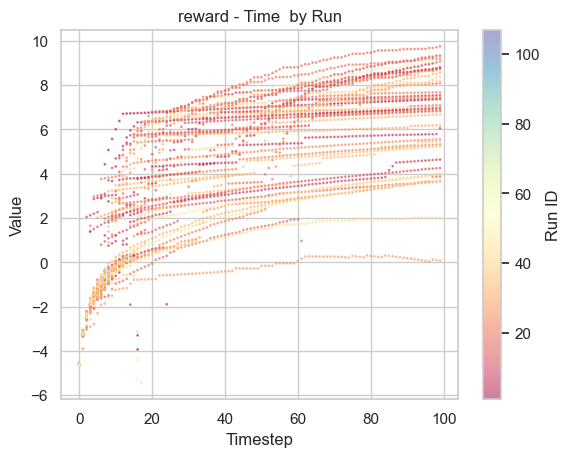

In [20]:
import matplotlib.pyplot as plt
import numpy as np
cma = 'Spectral' #cubehelix

def scatter_over_time(category = 'reward', metric_name = 'Time'):             

    # Filter your data
    plot_data = df_long[(df_long['metric_category'] == category) & 
                        (df_long['metric_name'] == metric_name)]
    
    # Create scatter plot with colorbar
    scatter = plt.scatter(plot_data['timestep'], np.log(plot_data['value'])*2, s=1,
                         c=plot_data['run_id'], cmap=cma, alpha = 0.5)
    plt.colorbar(scatter, label='Run ID')
    plt.xlabel('Timestep')
    plt.ylabel('Value')
    plt.title(f'{category} - {metric_name}  by Run')
    plt.show()

scatter_over_time()

In [21]:
print(df_long[(df_long['run_id'] == 40) & (df_long['metric_category'] == 'reward')])

        run_id  timestep metric_name      value metric_category
135181      40         0        Time   0.100073          reward
135182      40         1        Time   0.196680          reward
135183      40         2        Time   0.291260          reward
135184      40         3        Time   0.391333          reward
135185      40         4        Time   0.506384          reward
...        ...       ...         ...        ...             ...
135276      40        95        Time  33.828880          reward
135277      40        96        Time  33.933614          reward
135278      40        97        Time  34.038349          reward
135279      40        98        Time  34.143083          reward
135280      40        99        Time  34.247818          reward

[100 rows x 5 columns]


C:\Users\frogl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


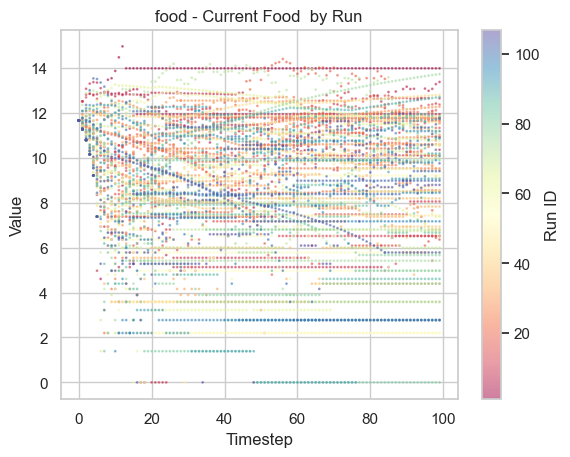

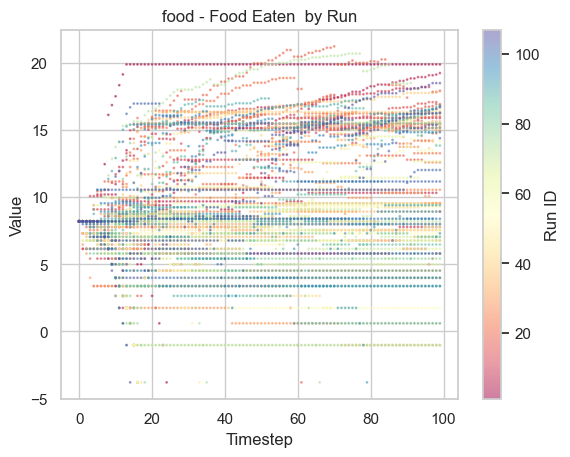

C:\Users\frogl\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


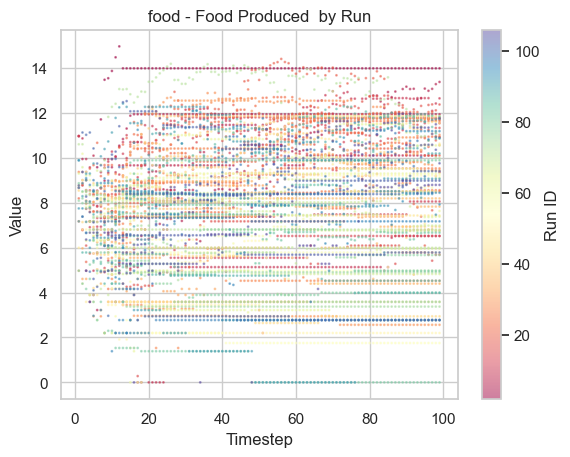

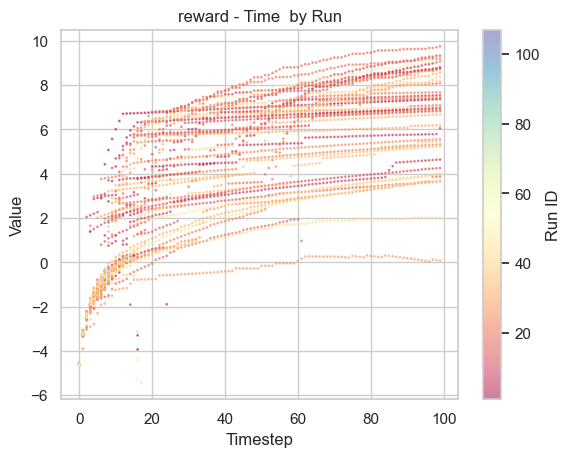

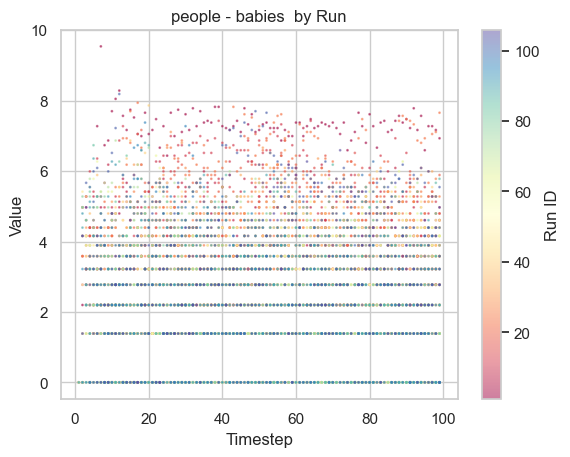

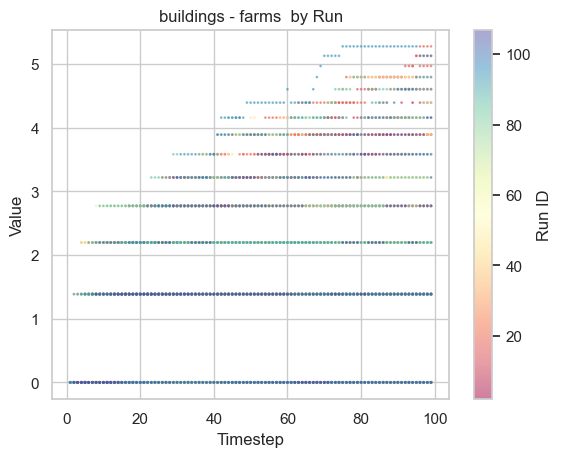

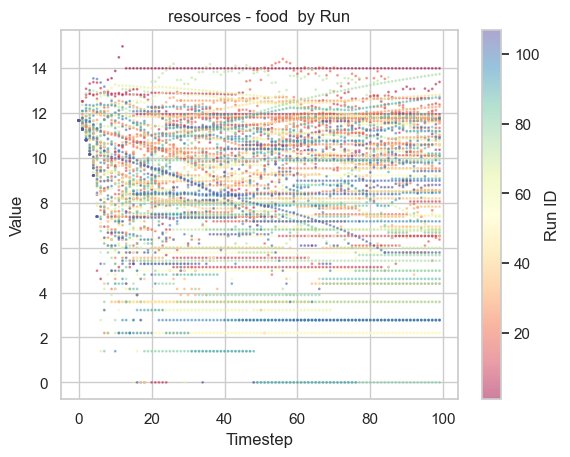

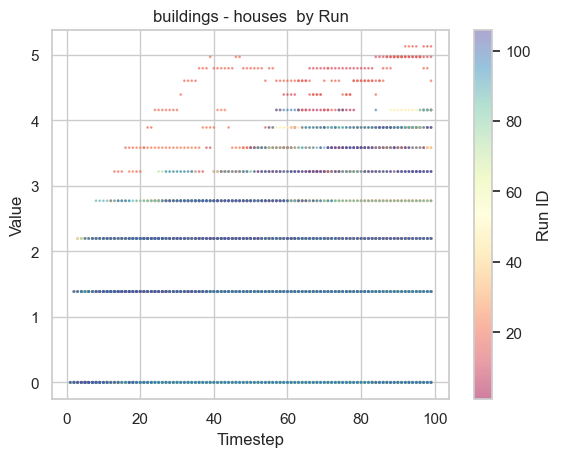

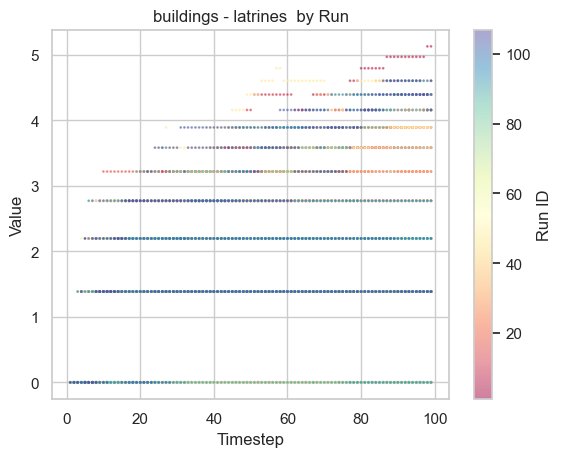

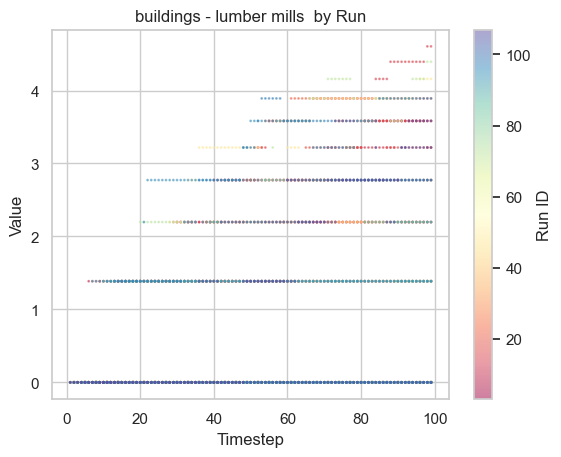

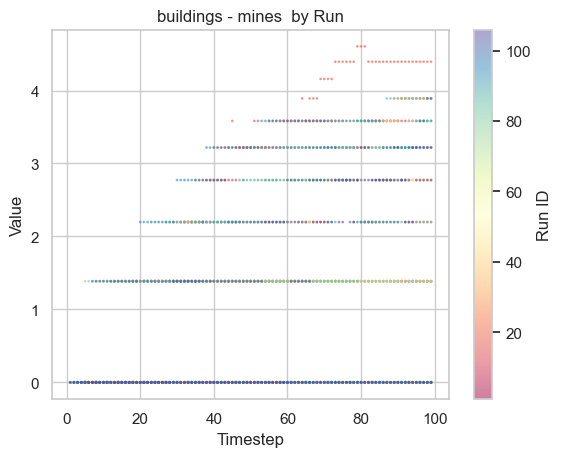

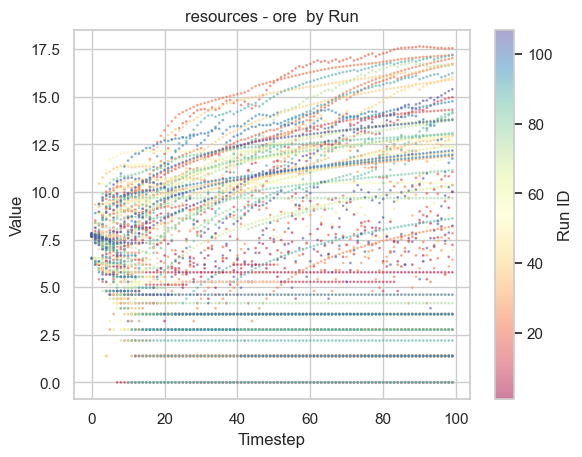

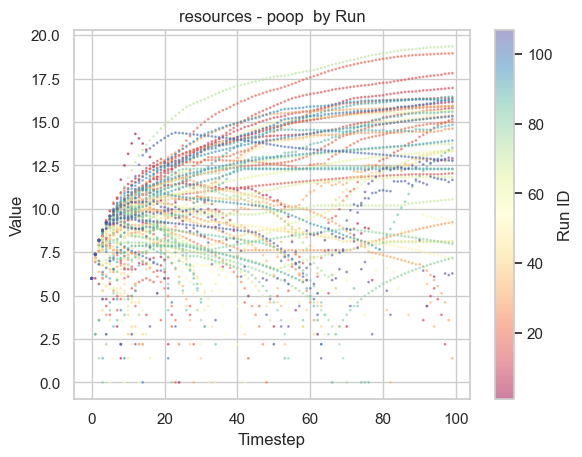

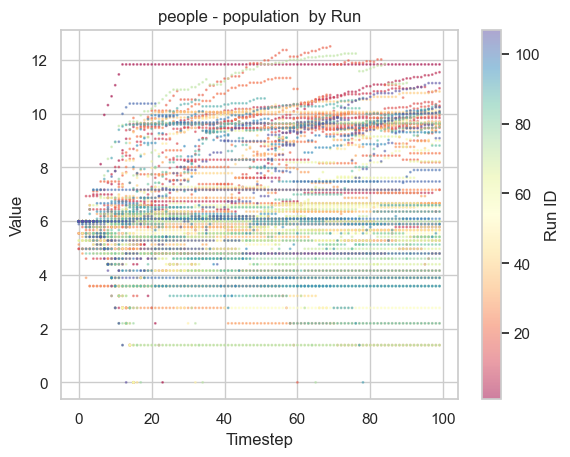

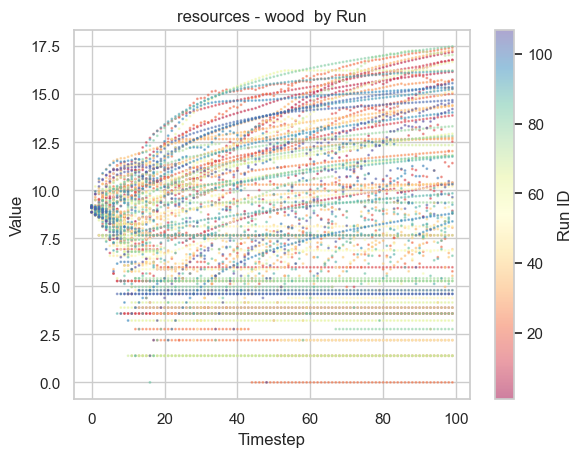

In [22]:
categories = np.unique(df_long['metric_category'])
metric_names = np.unique(df_long['metric_name'])

for metric in metric_names:
    for category in categories:

        combination_exists = len(df_long[(df_long['metric_category'] == category) & 
                                        (df_long['metric_name'] == metric)]) > 0
        
        if combination_exists:
            scatter_over_time(category, metric)
        else:
            pass  # or print(f"No data for {category} - {metric}")

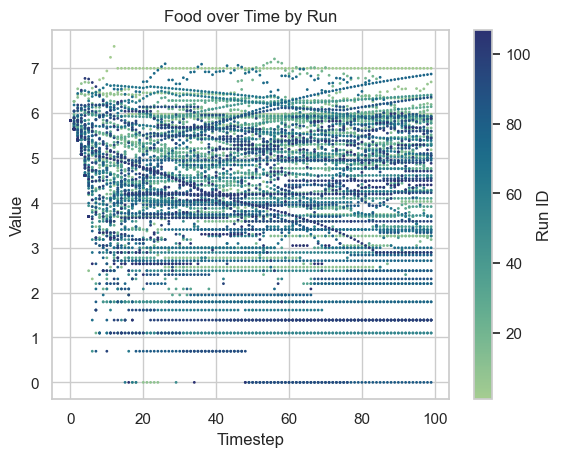

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Filter your data
plot_data = df_long[(df_long['metric_category'] == 'resources') & 
                    (df_long['metric_name'] == 'food')]

# Create scatter plot with colorbar
scatter = plt.scatter(plot_data['timestep'], np.log(plot_data['value']), s=1,
                     c=plot_data['run_id'], cmap='crest')
plt.colorbar(scatter, label='Run ID')
plt.xlabel('Timestep')
plt.ylabel('Value')
plt.title('Food over Time by Run')
plt.show()

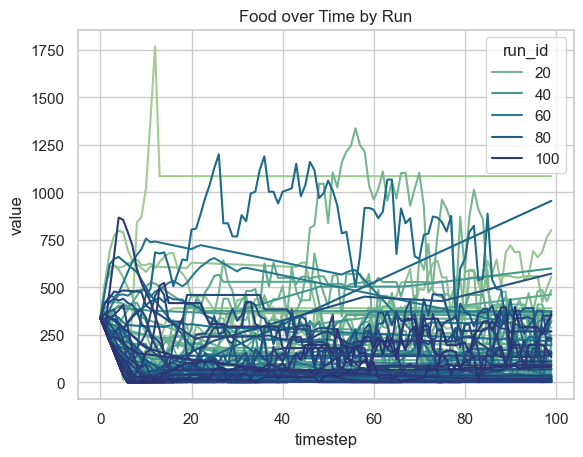

In [25]:
cmap = 'crest'

sns.lineplot(
    data=df_long[(df_long['metric_category'] == 'resources') & 
                 (df_long['metric_name'] == 'food')],
    x='timestep', y='value', hue='run_id', palette=cmap
)
#plt.colorbar()
plt.title('Food over Time by Run')
plt.show()

C:\Users\frogl\AppData\Local\Temp\ipykernel_18064\3949853471.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


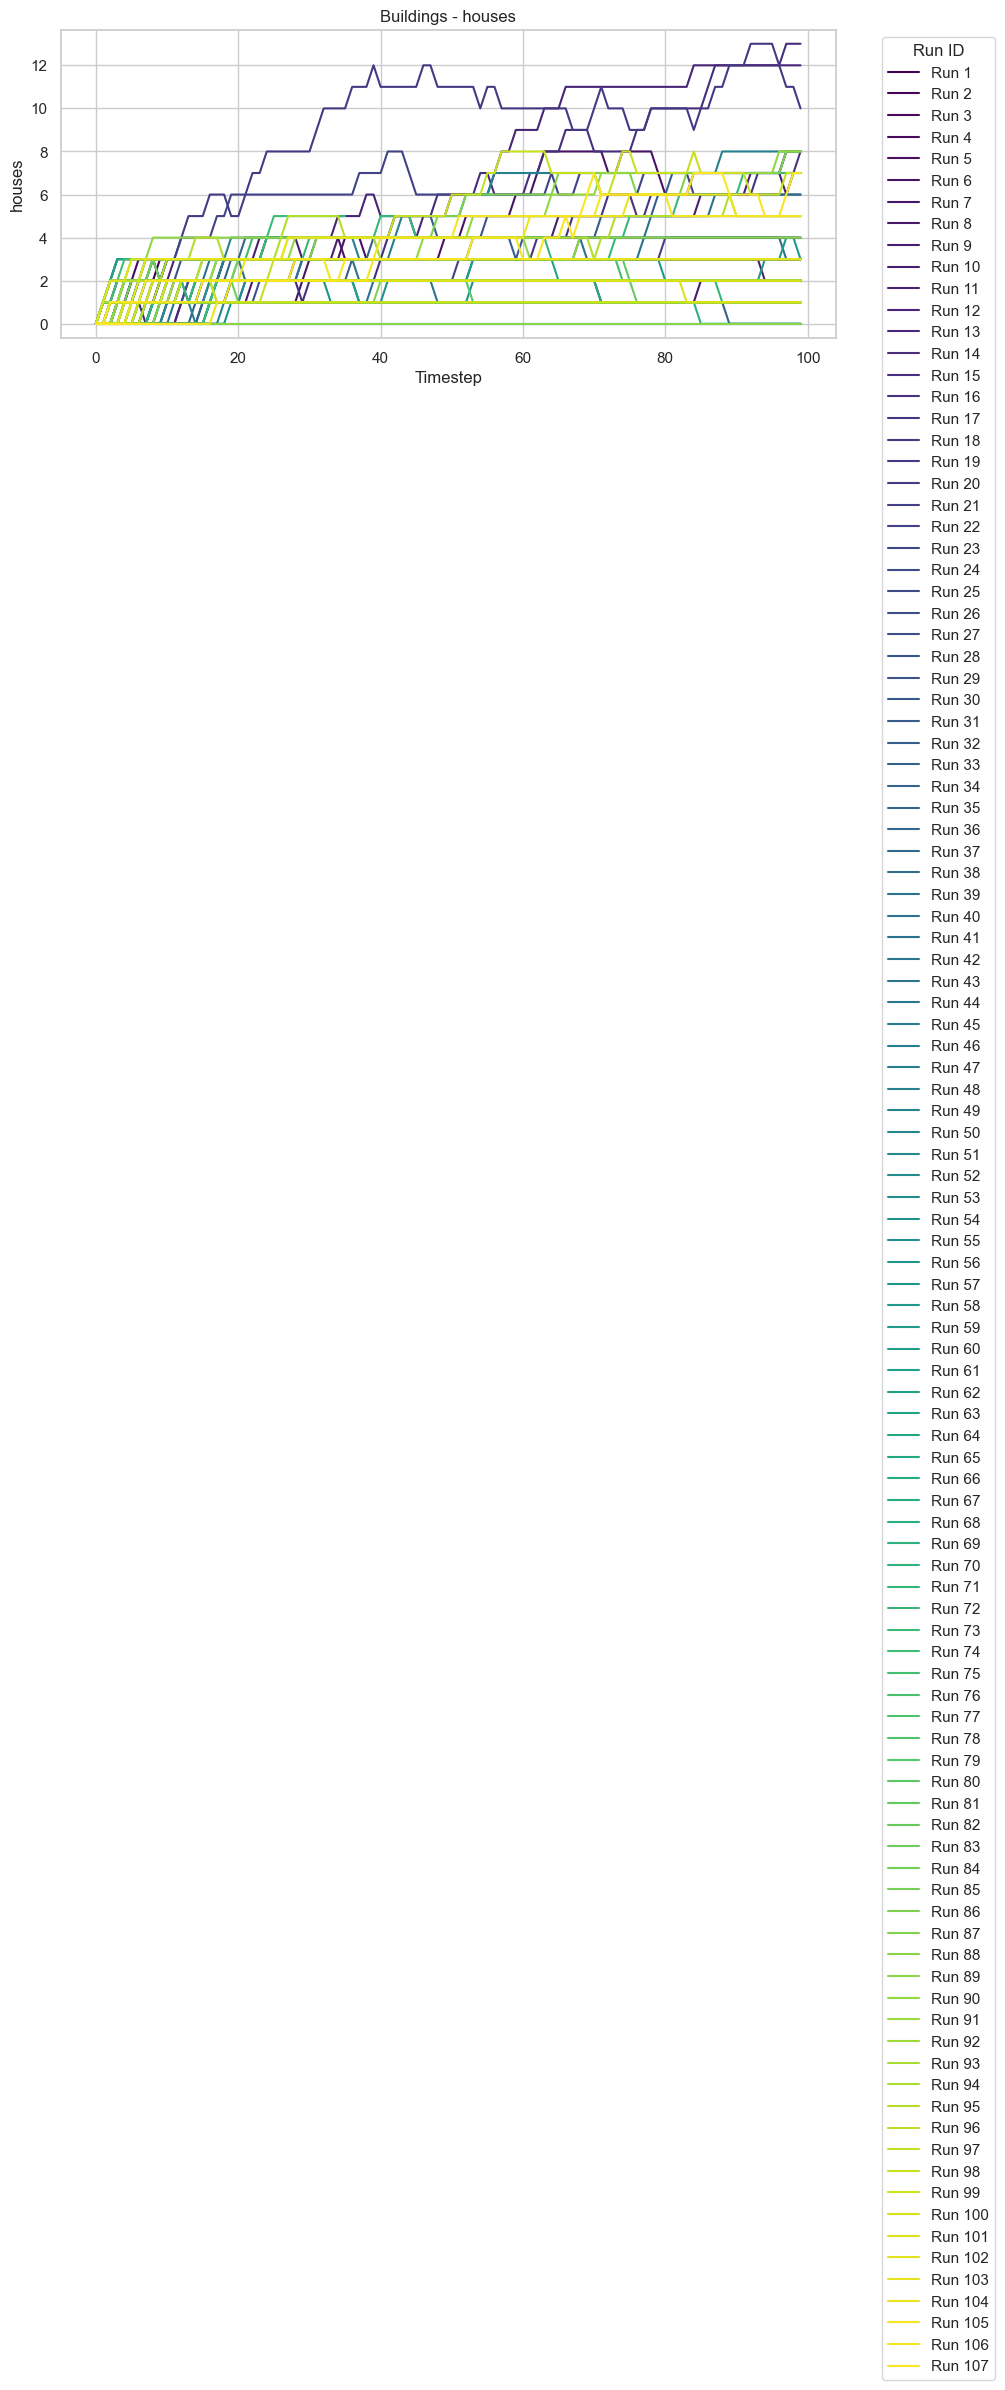

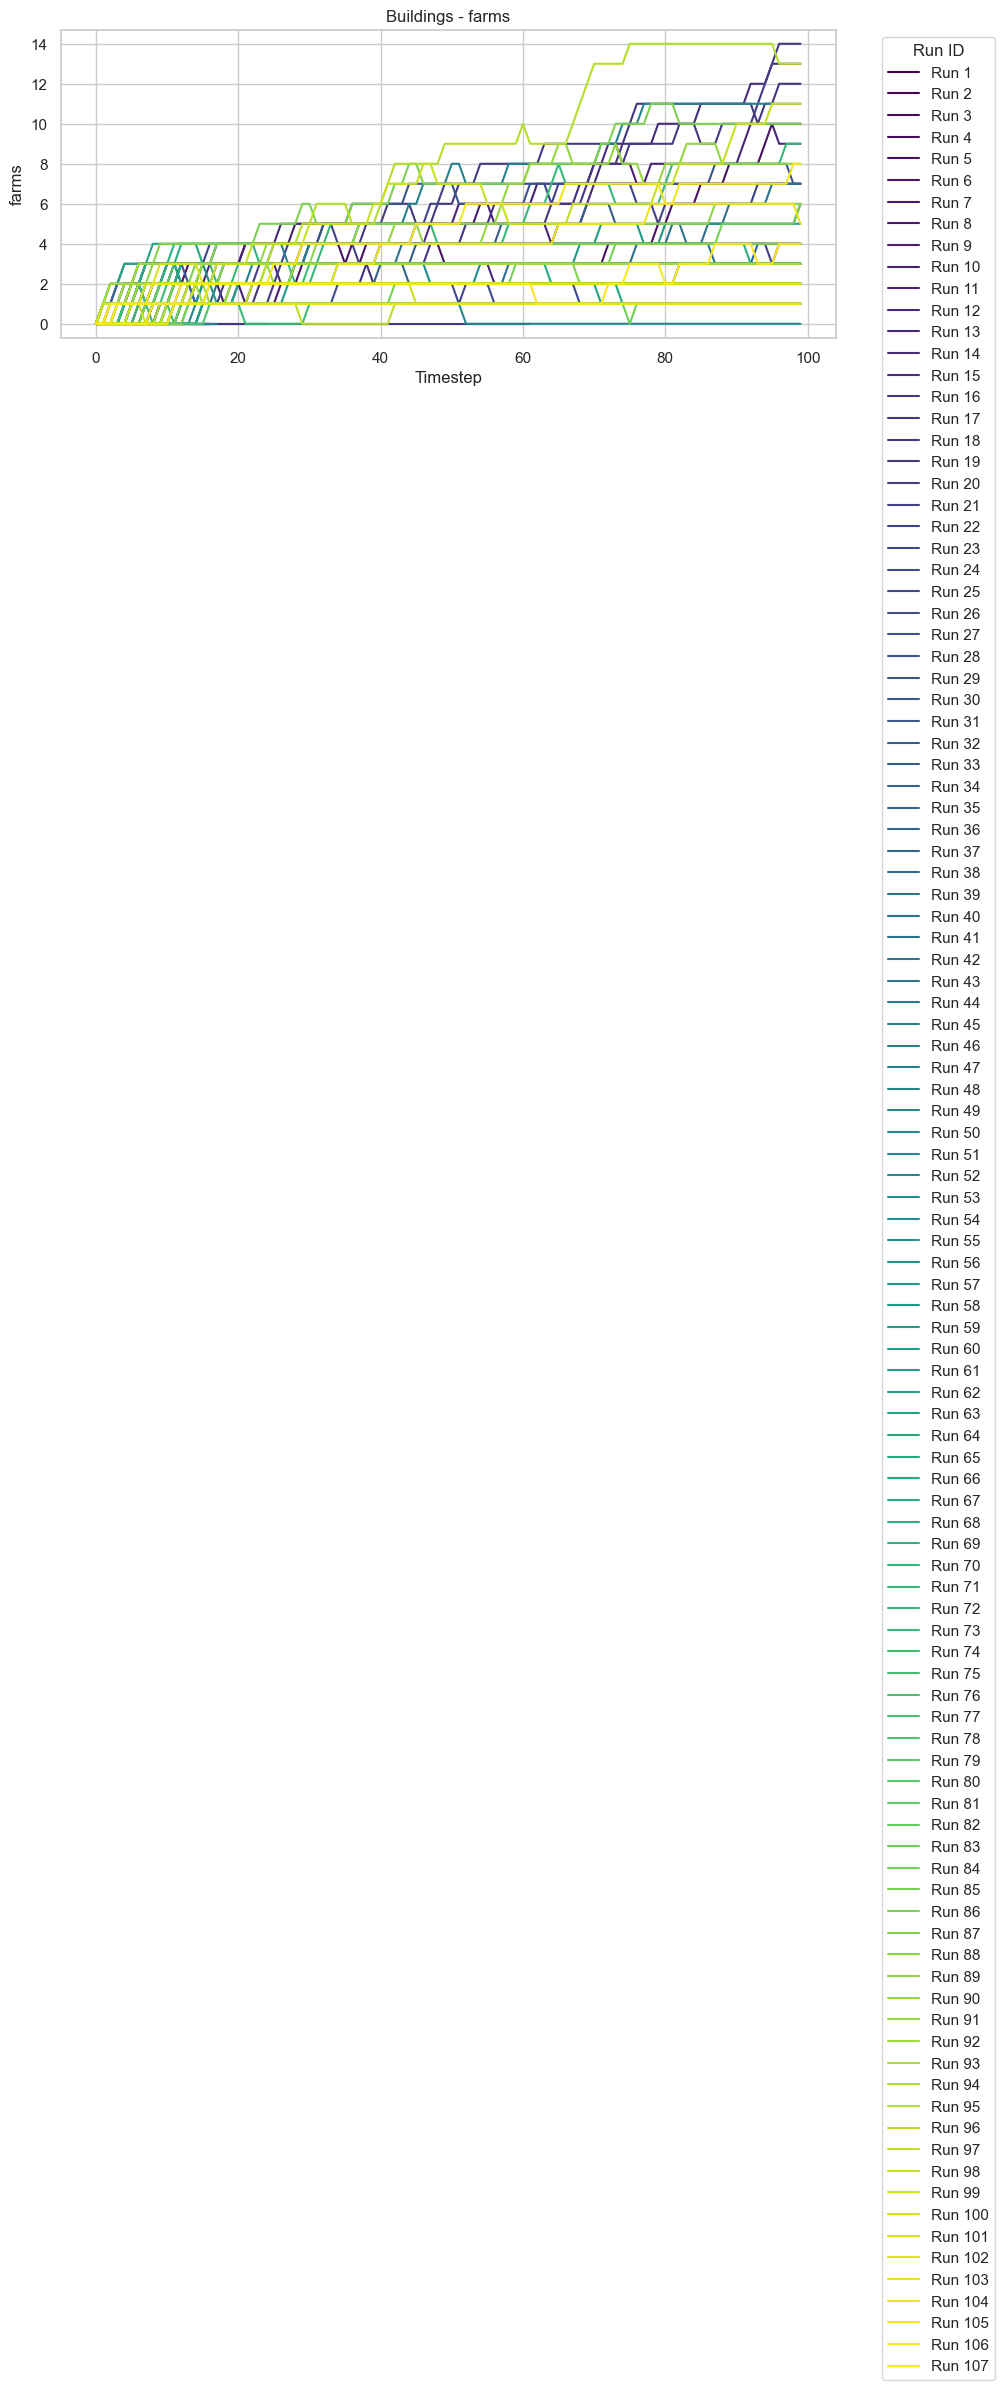

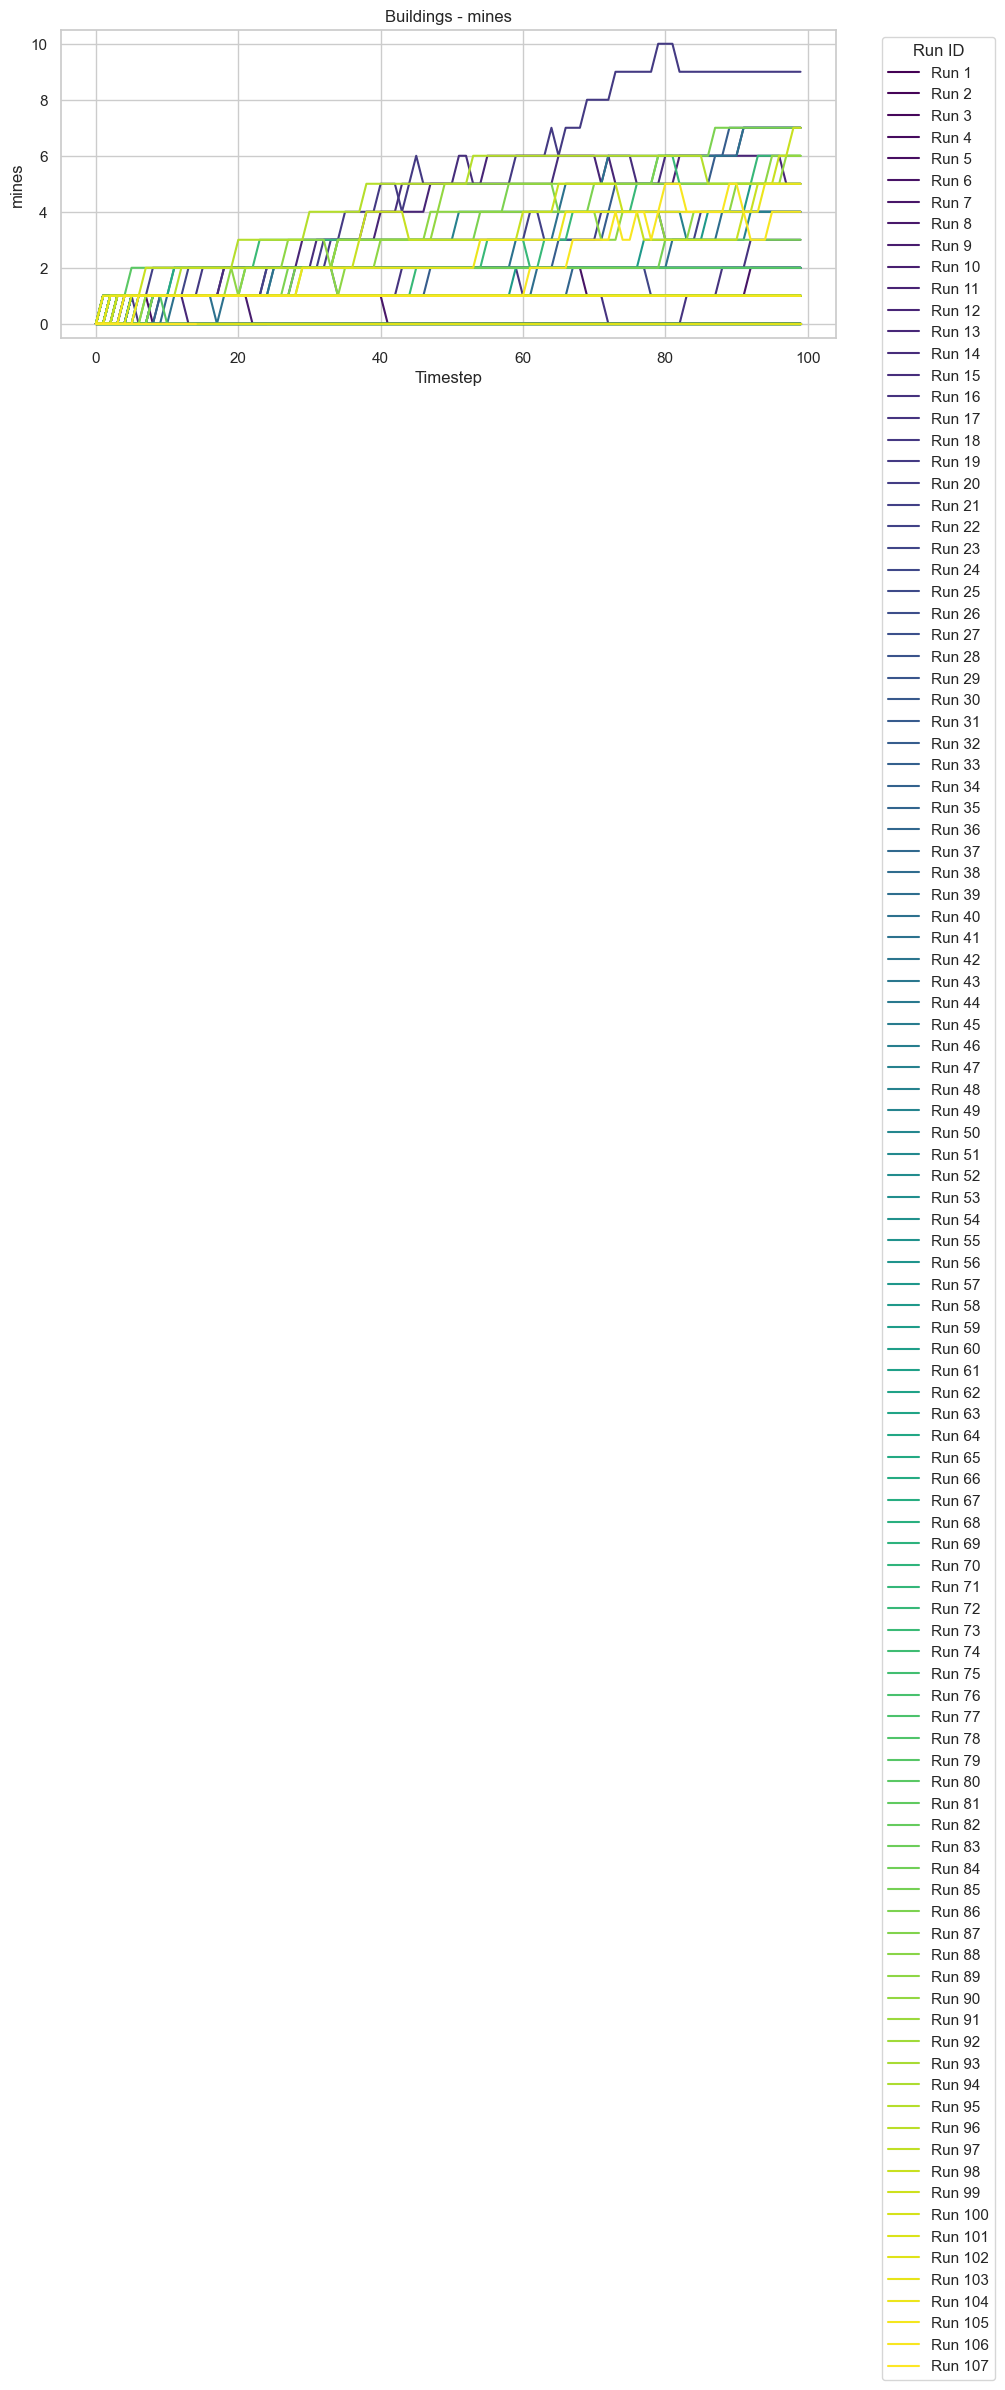

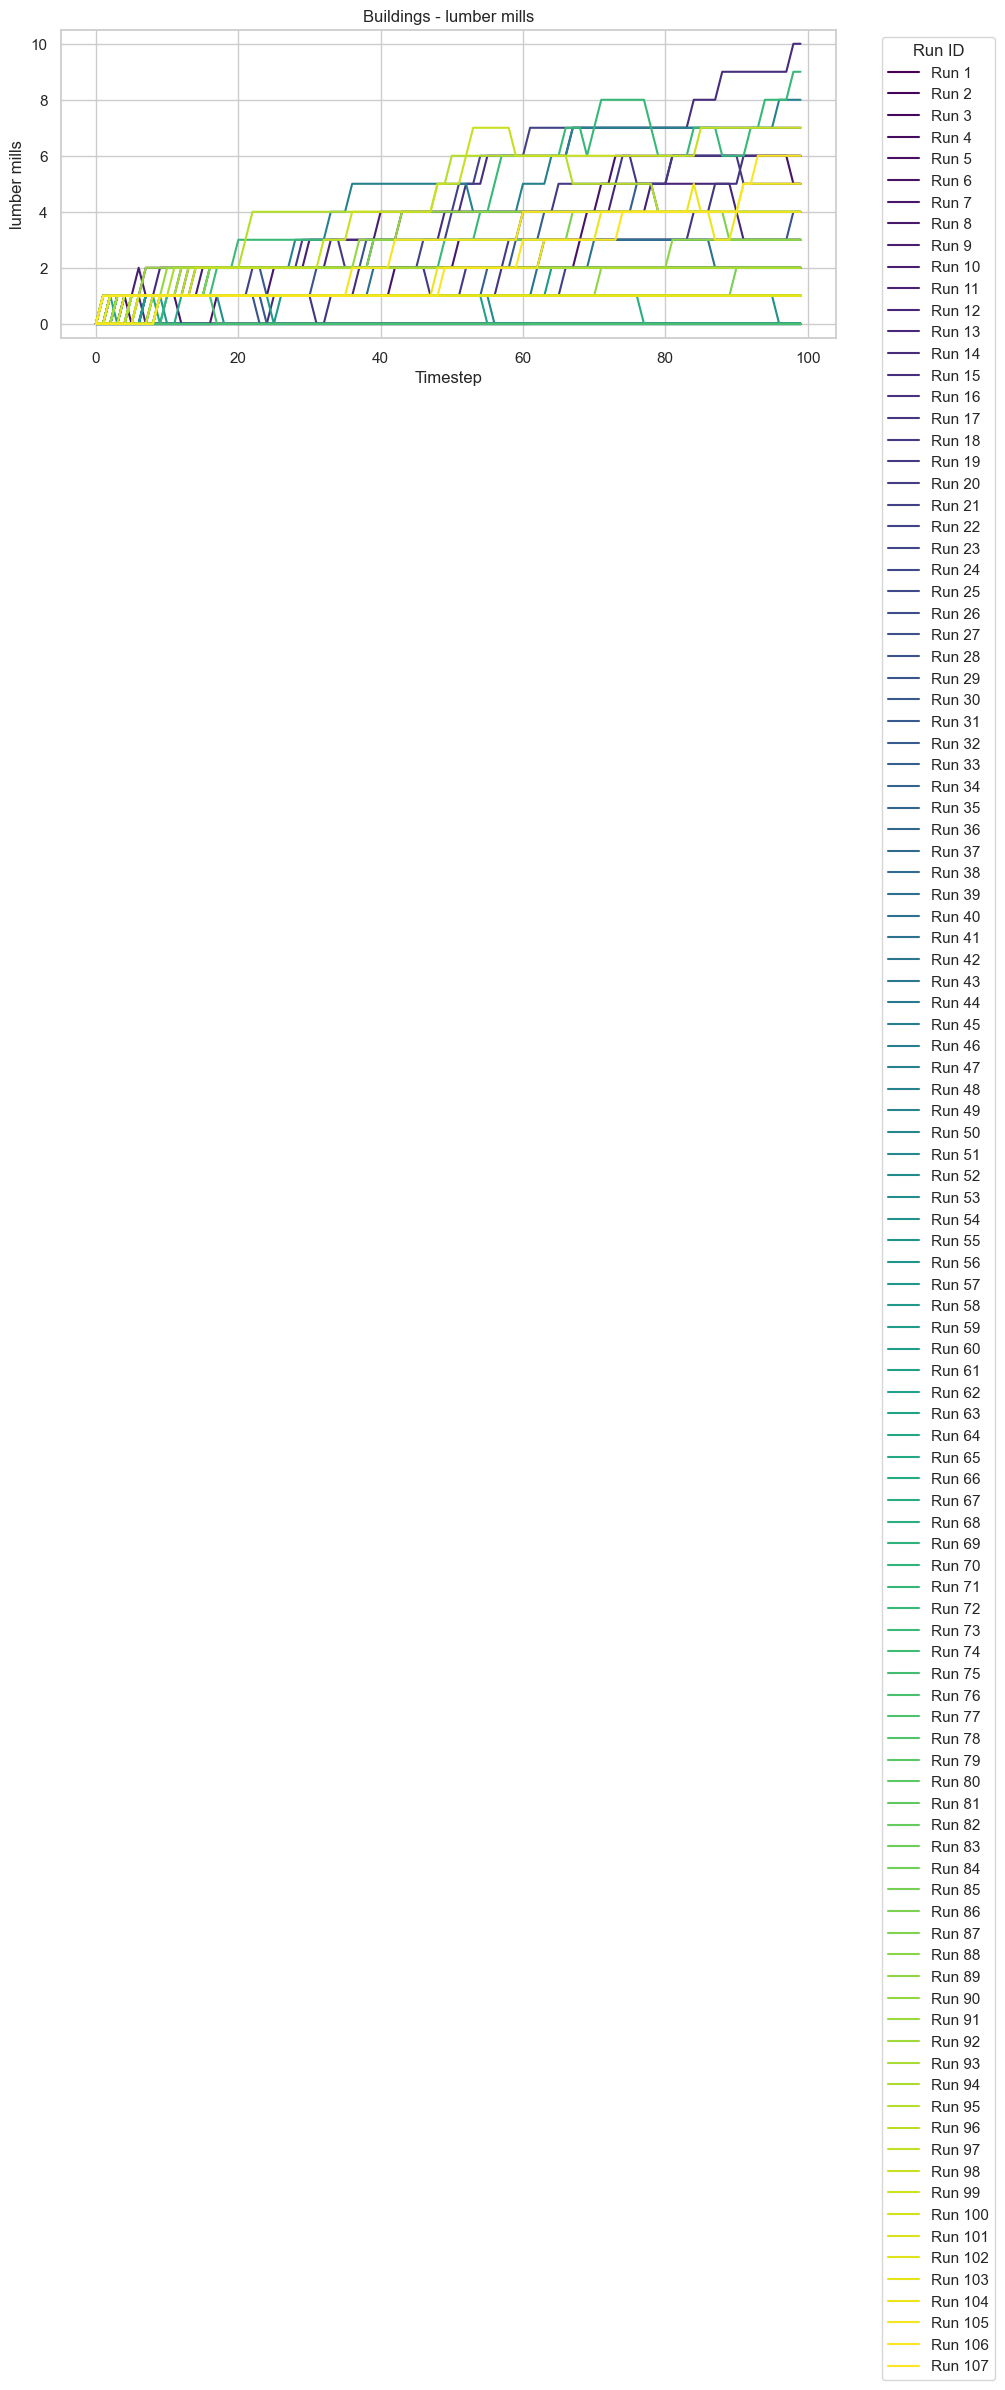

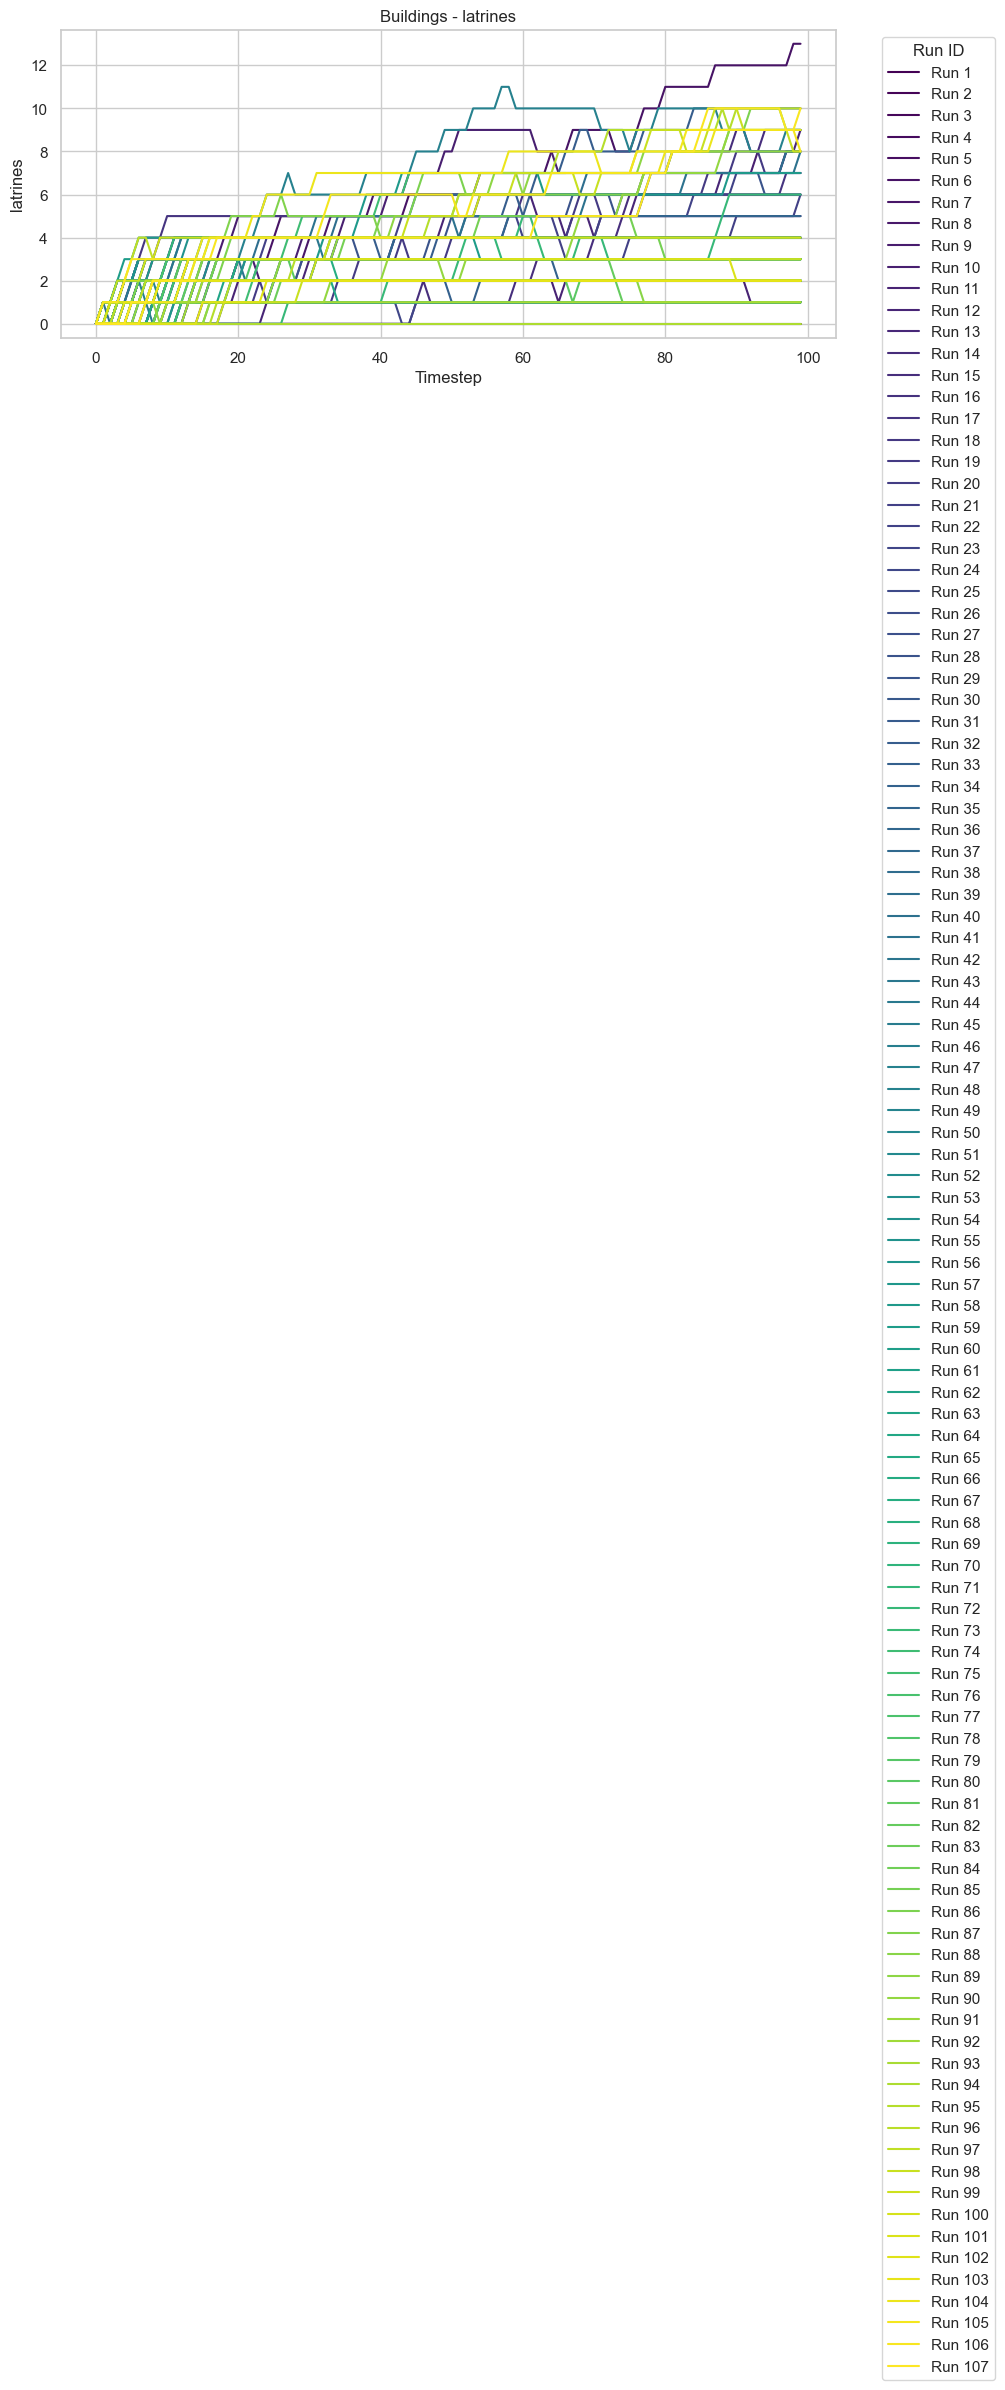

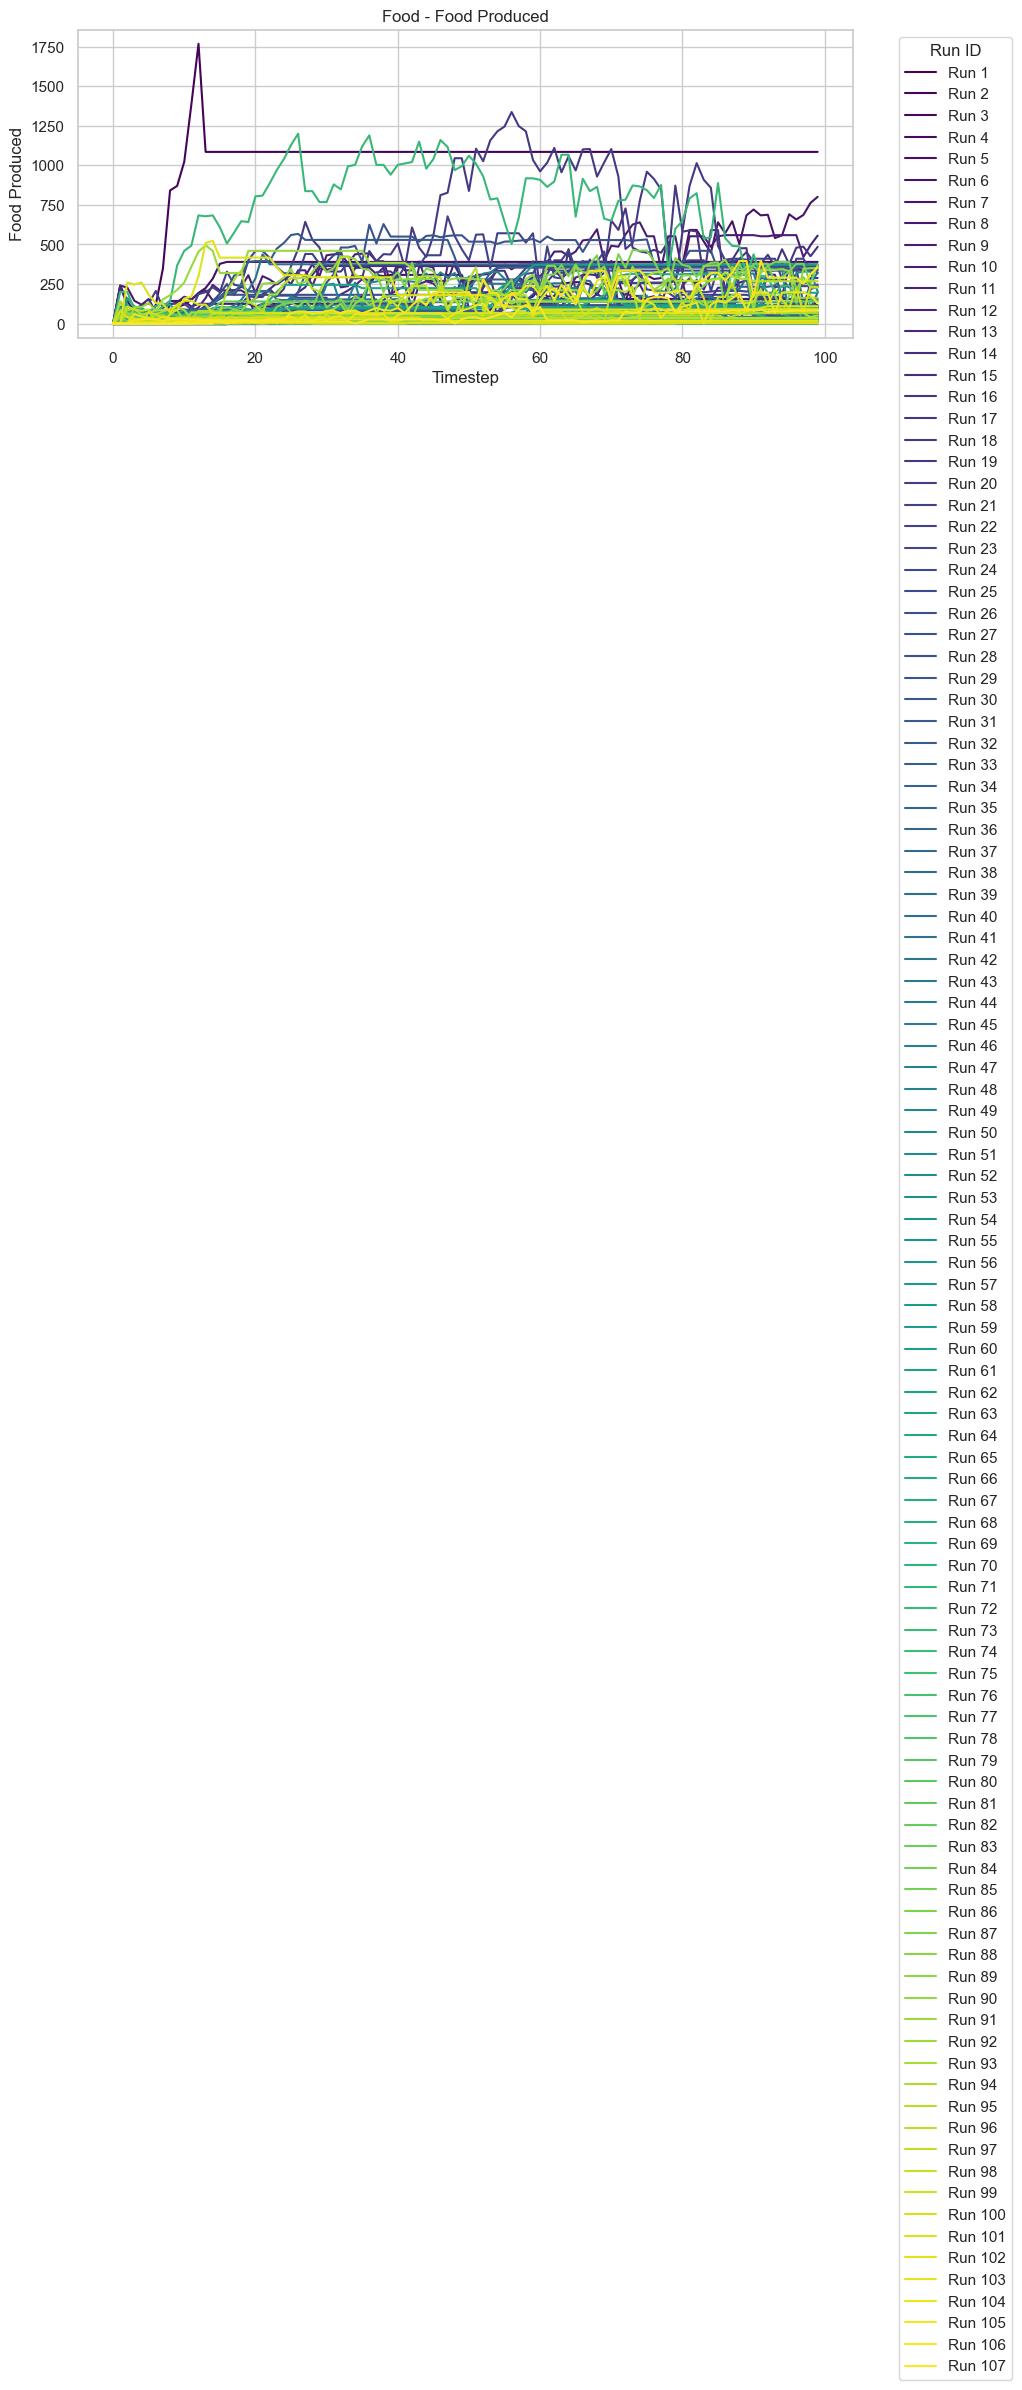

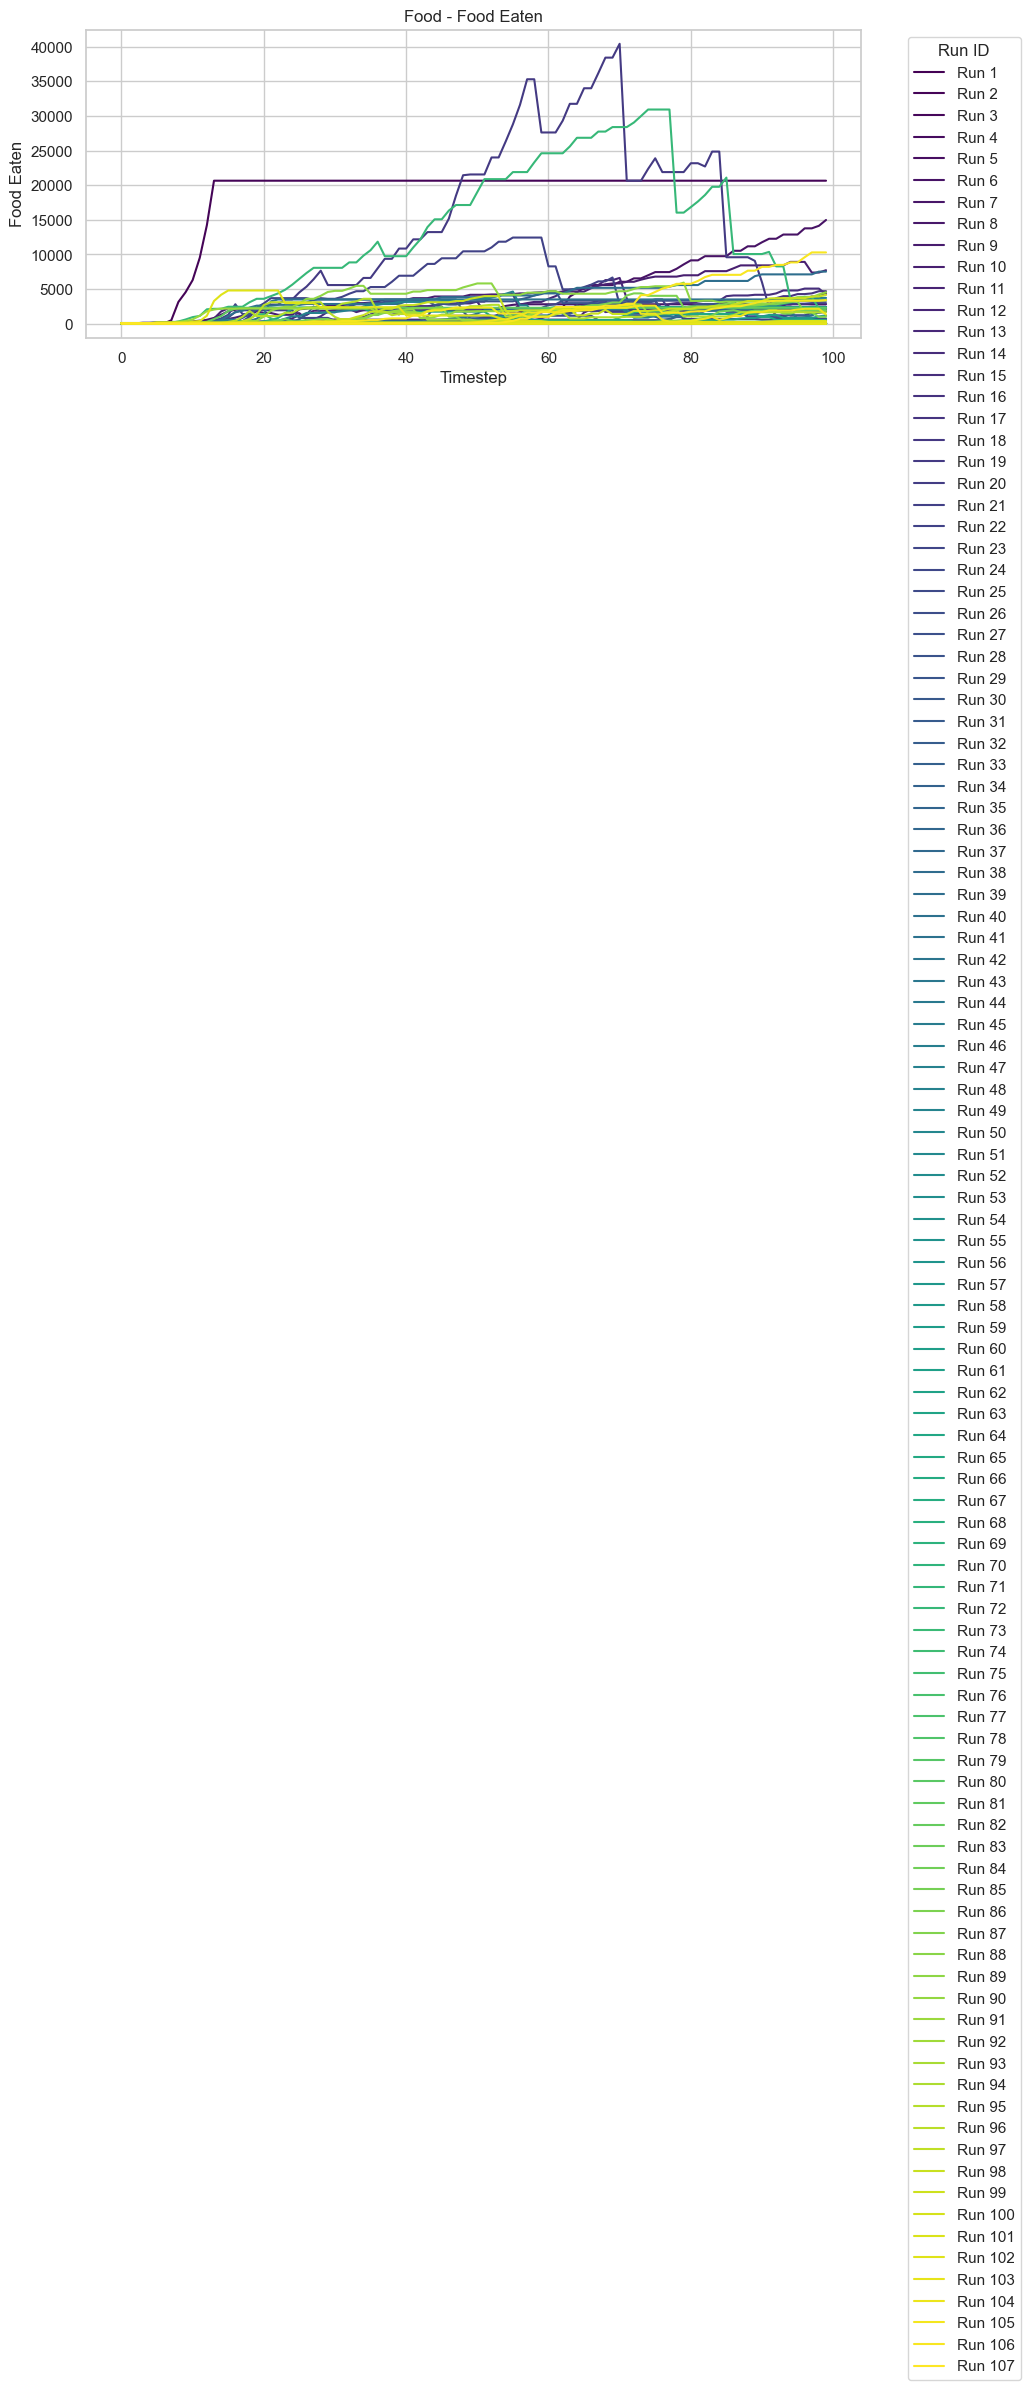

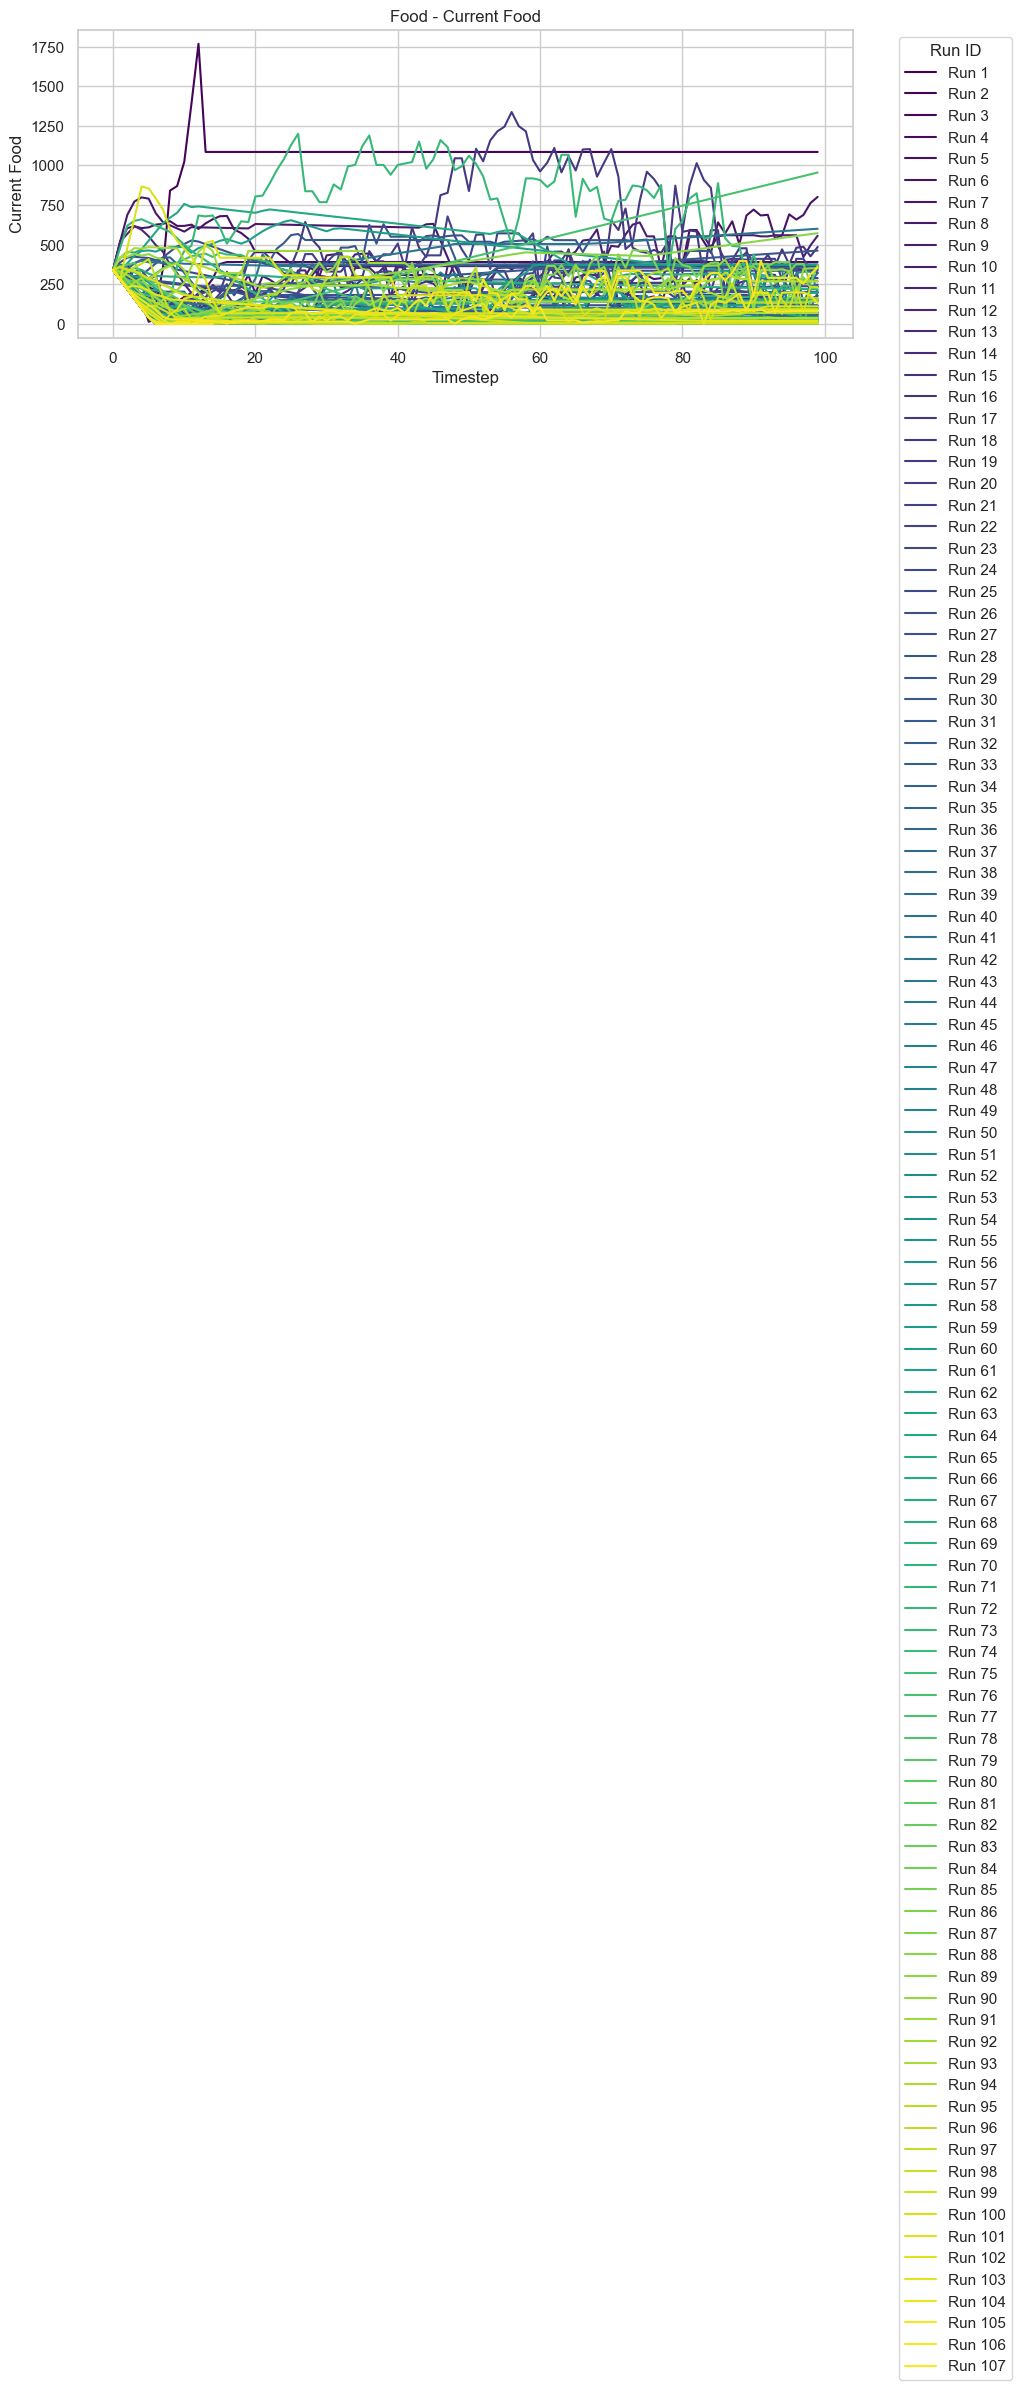

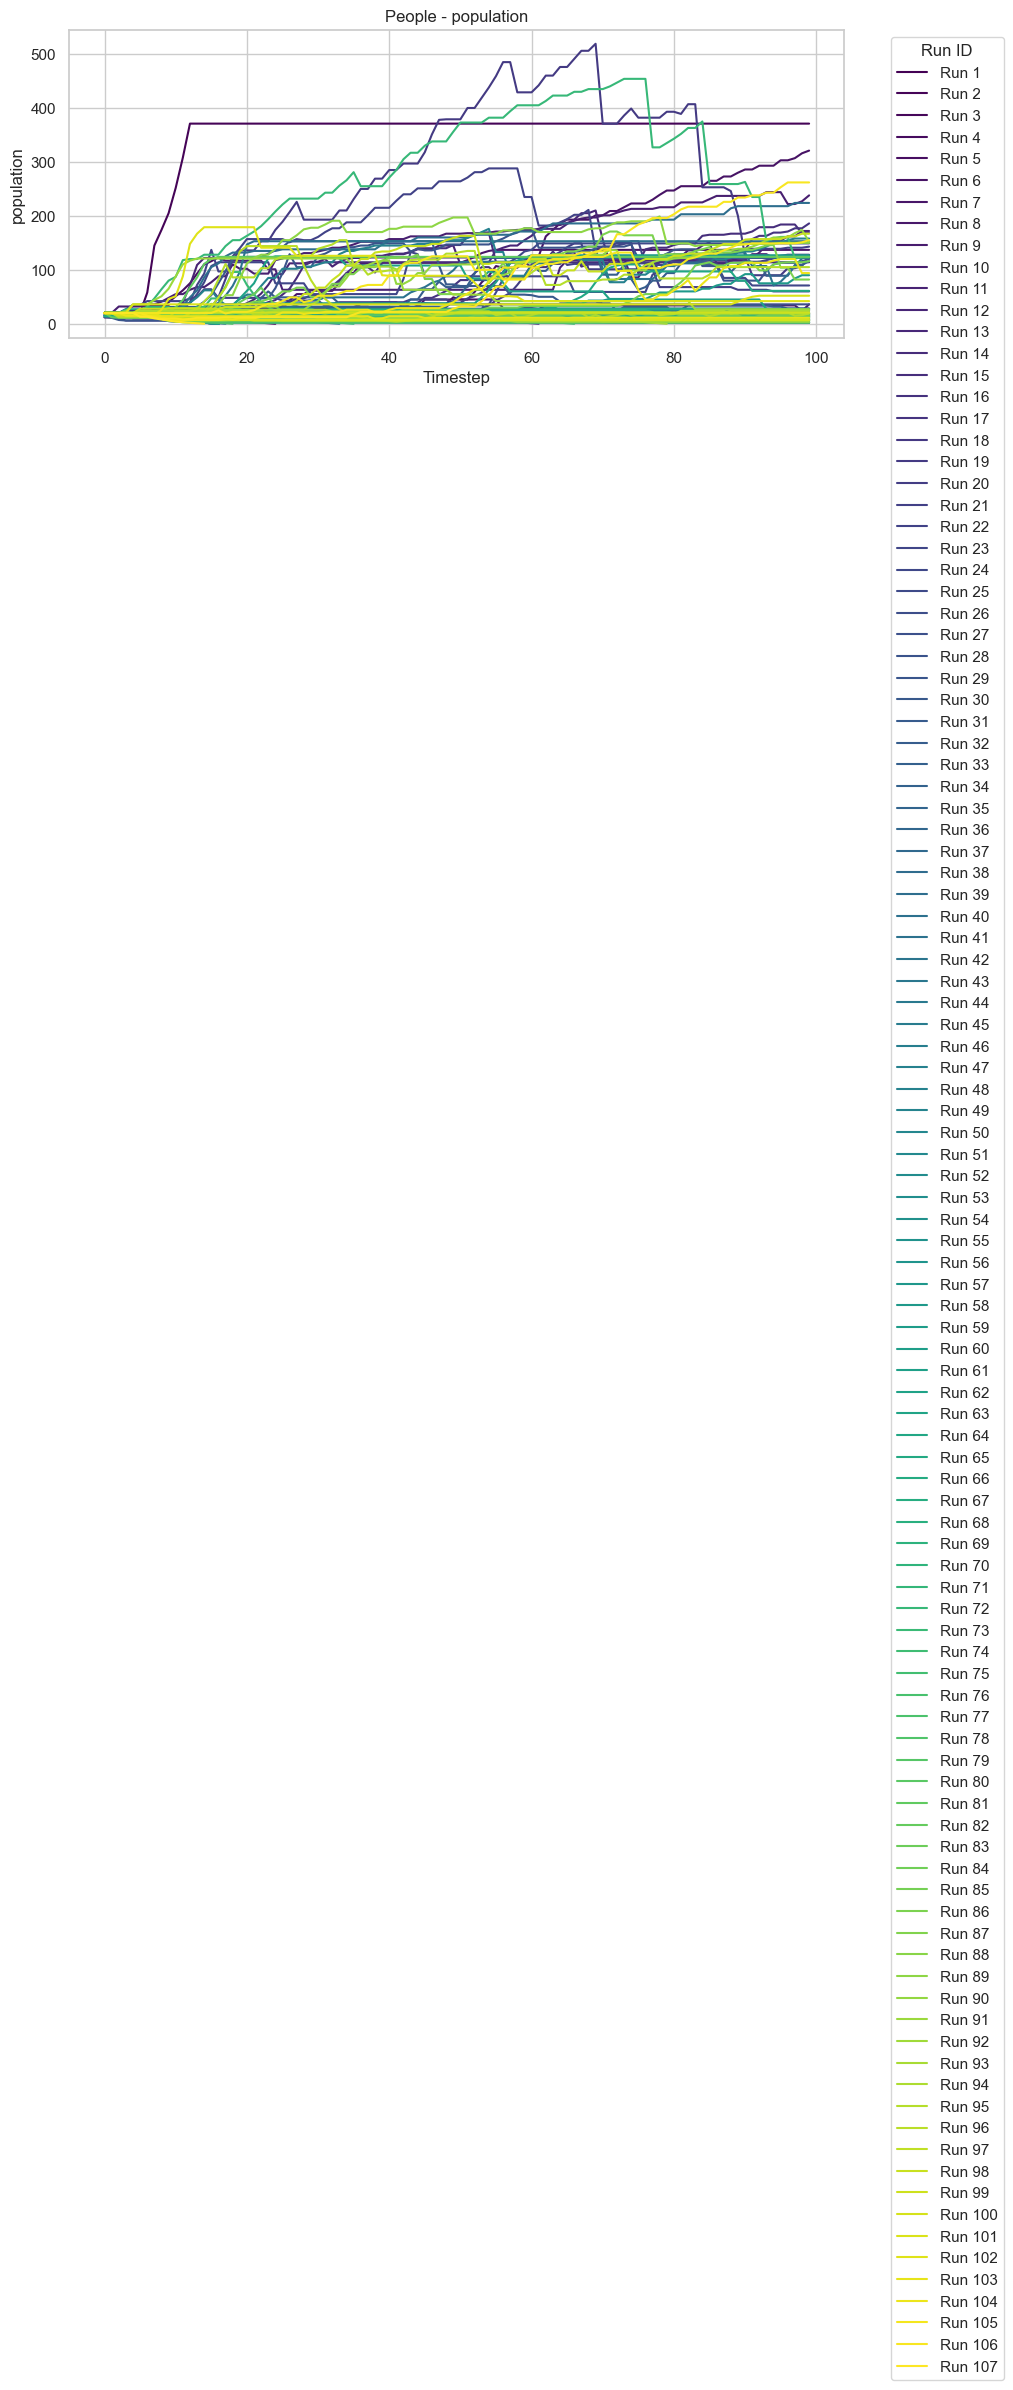

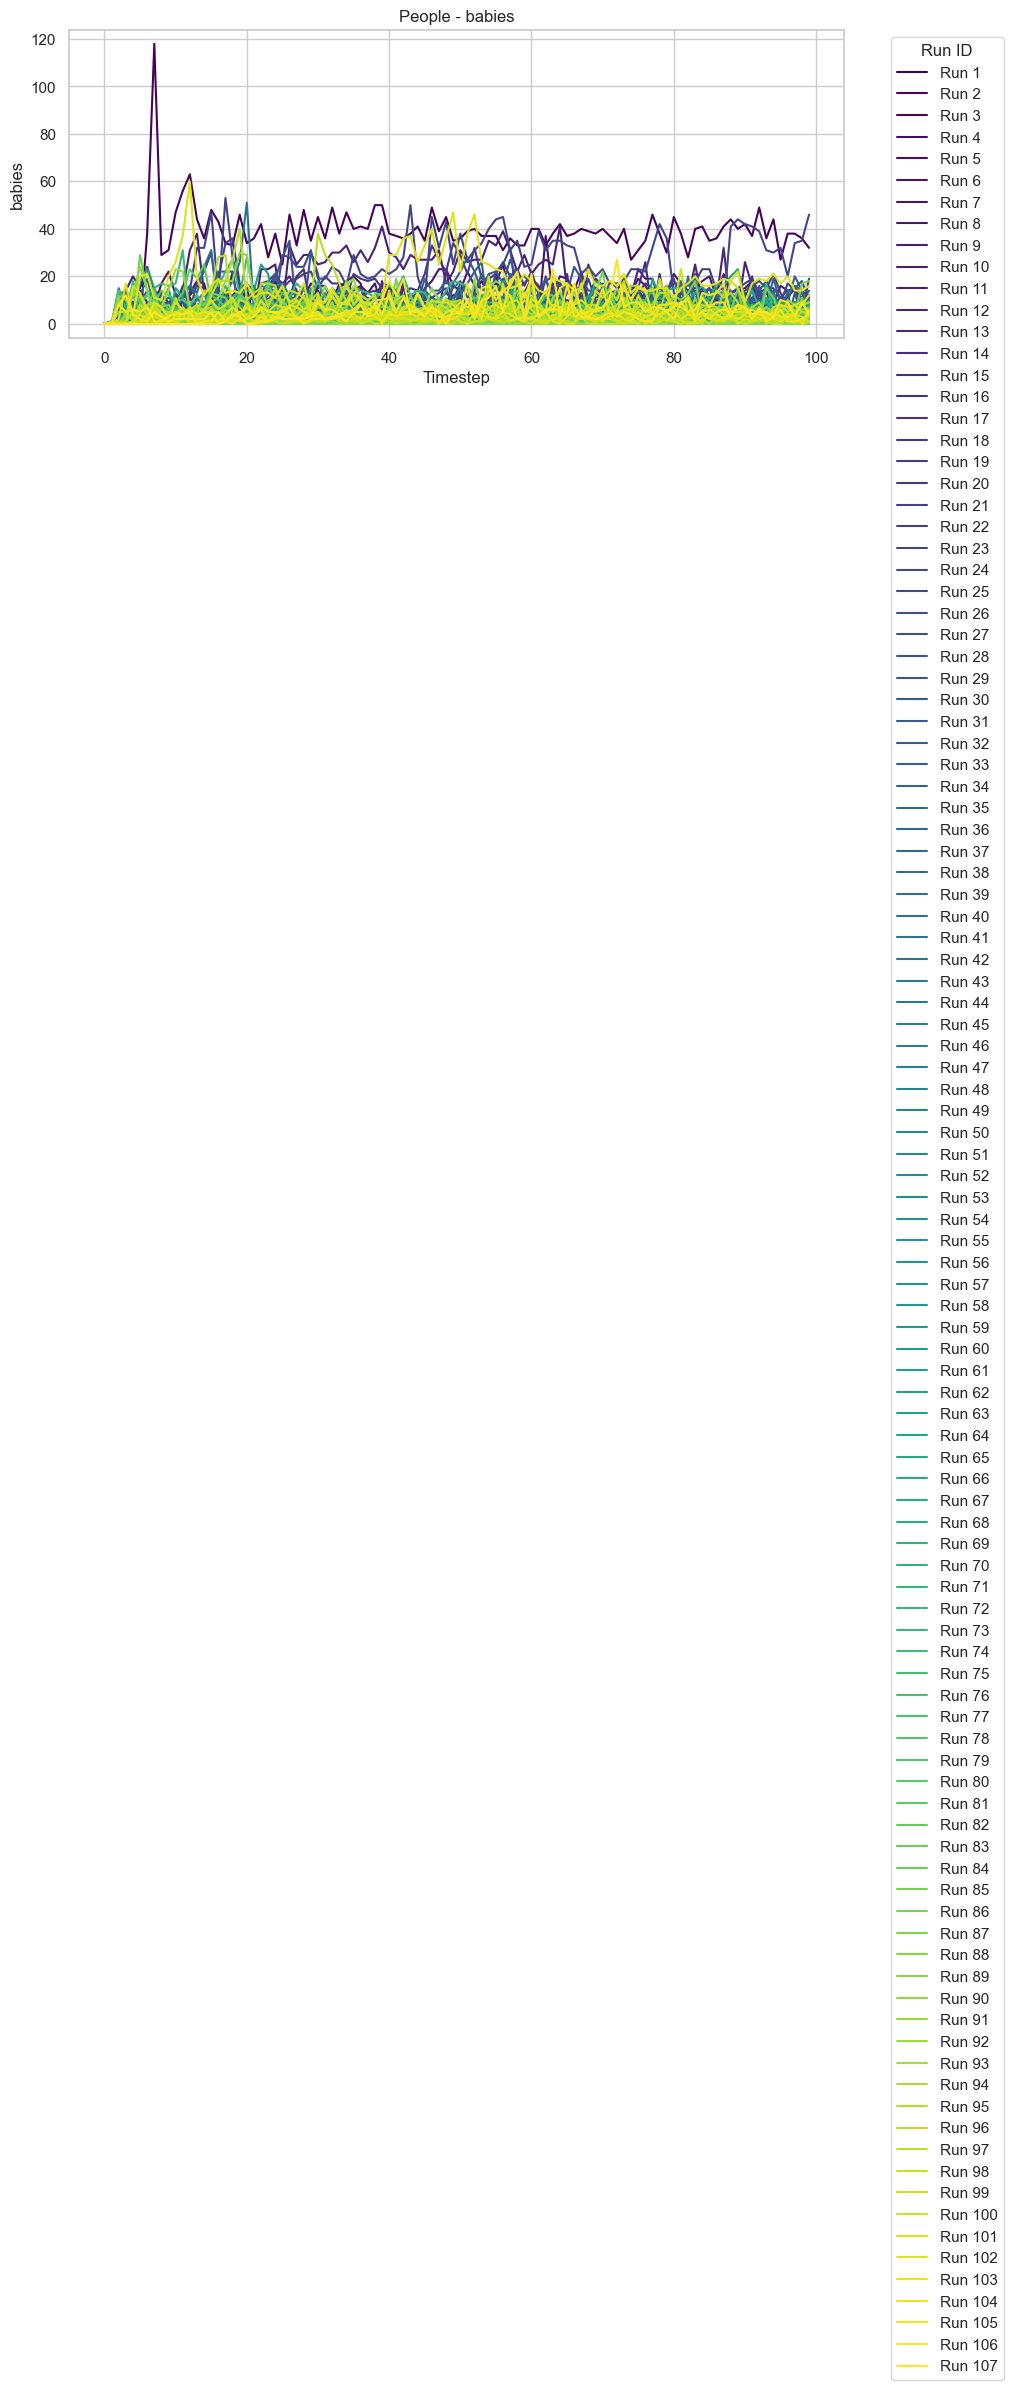

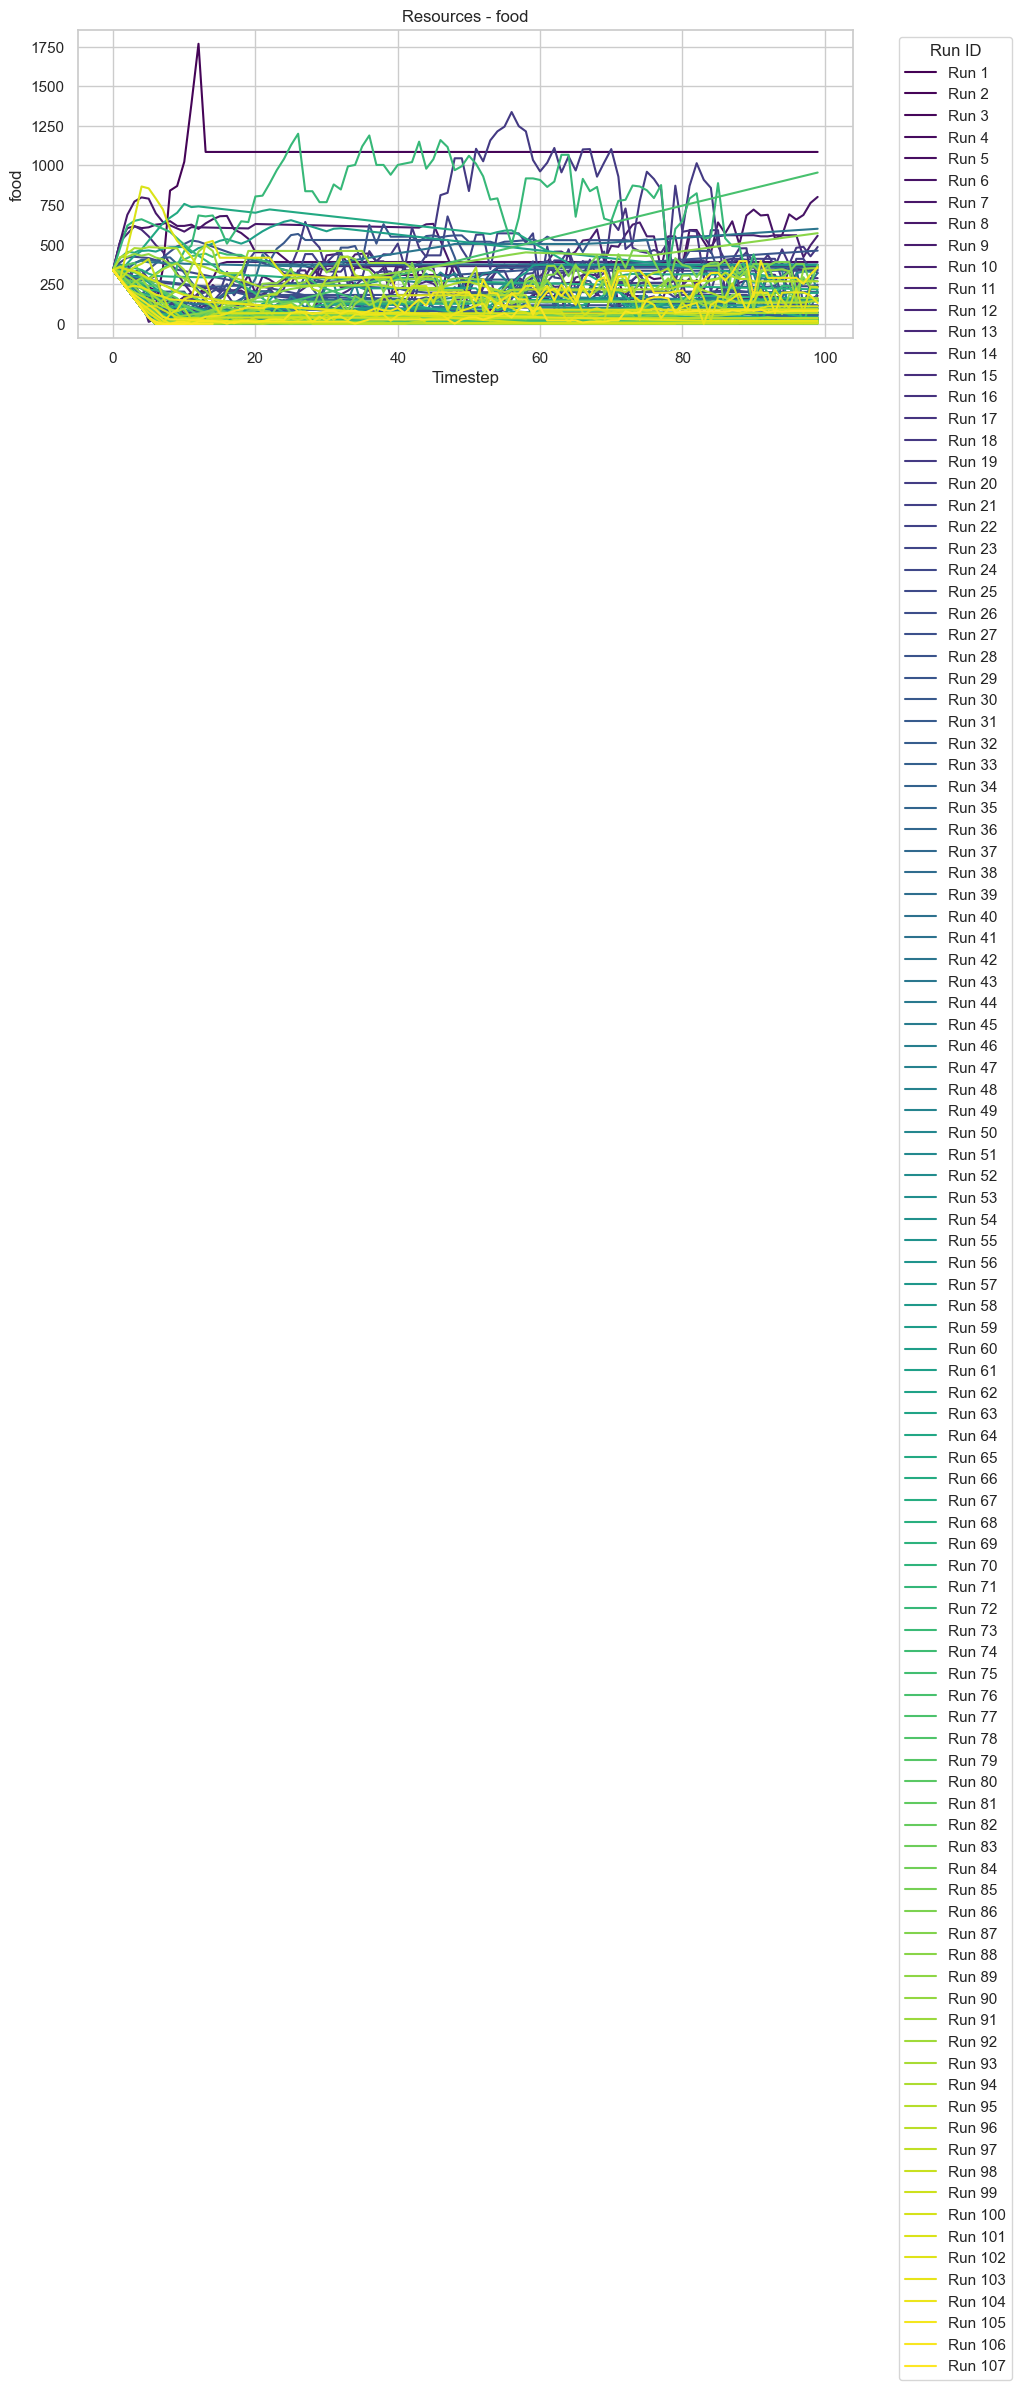

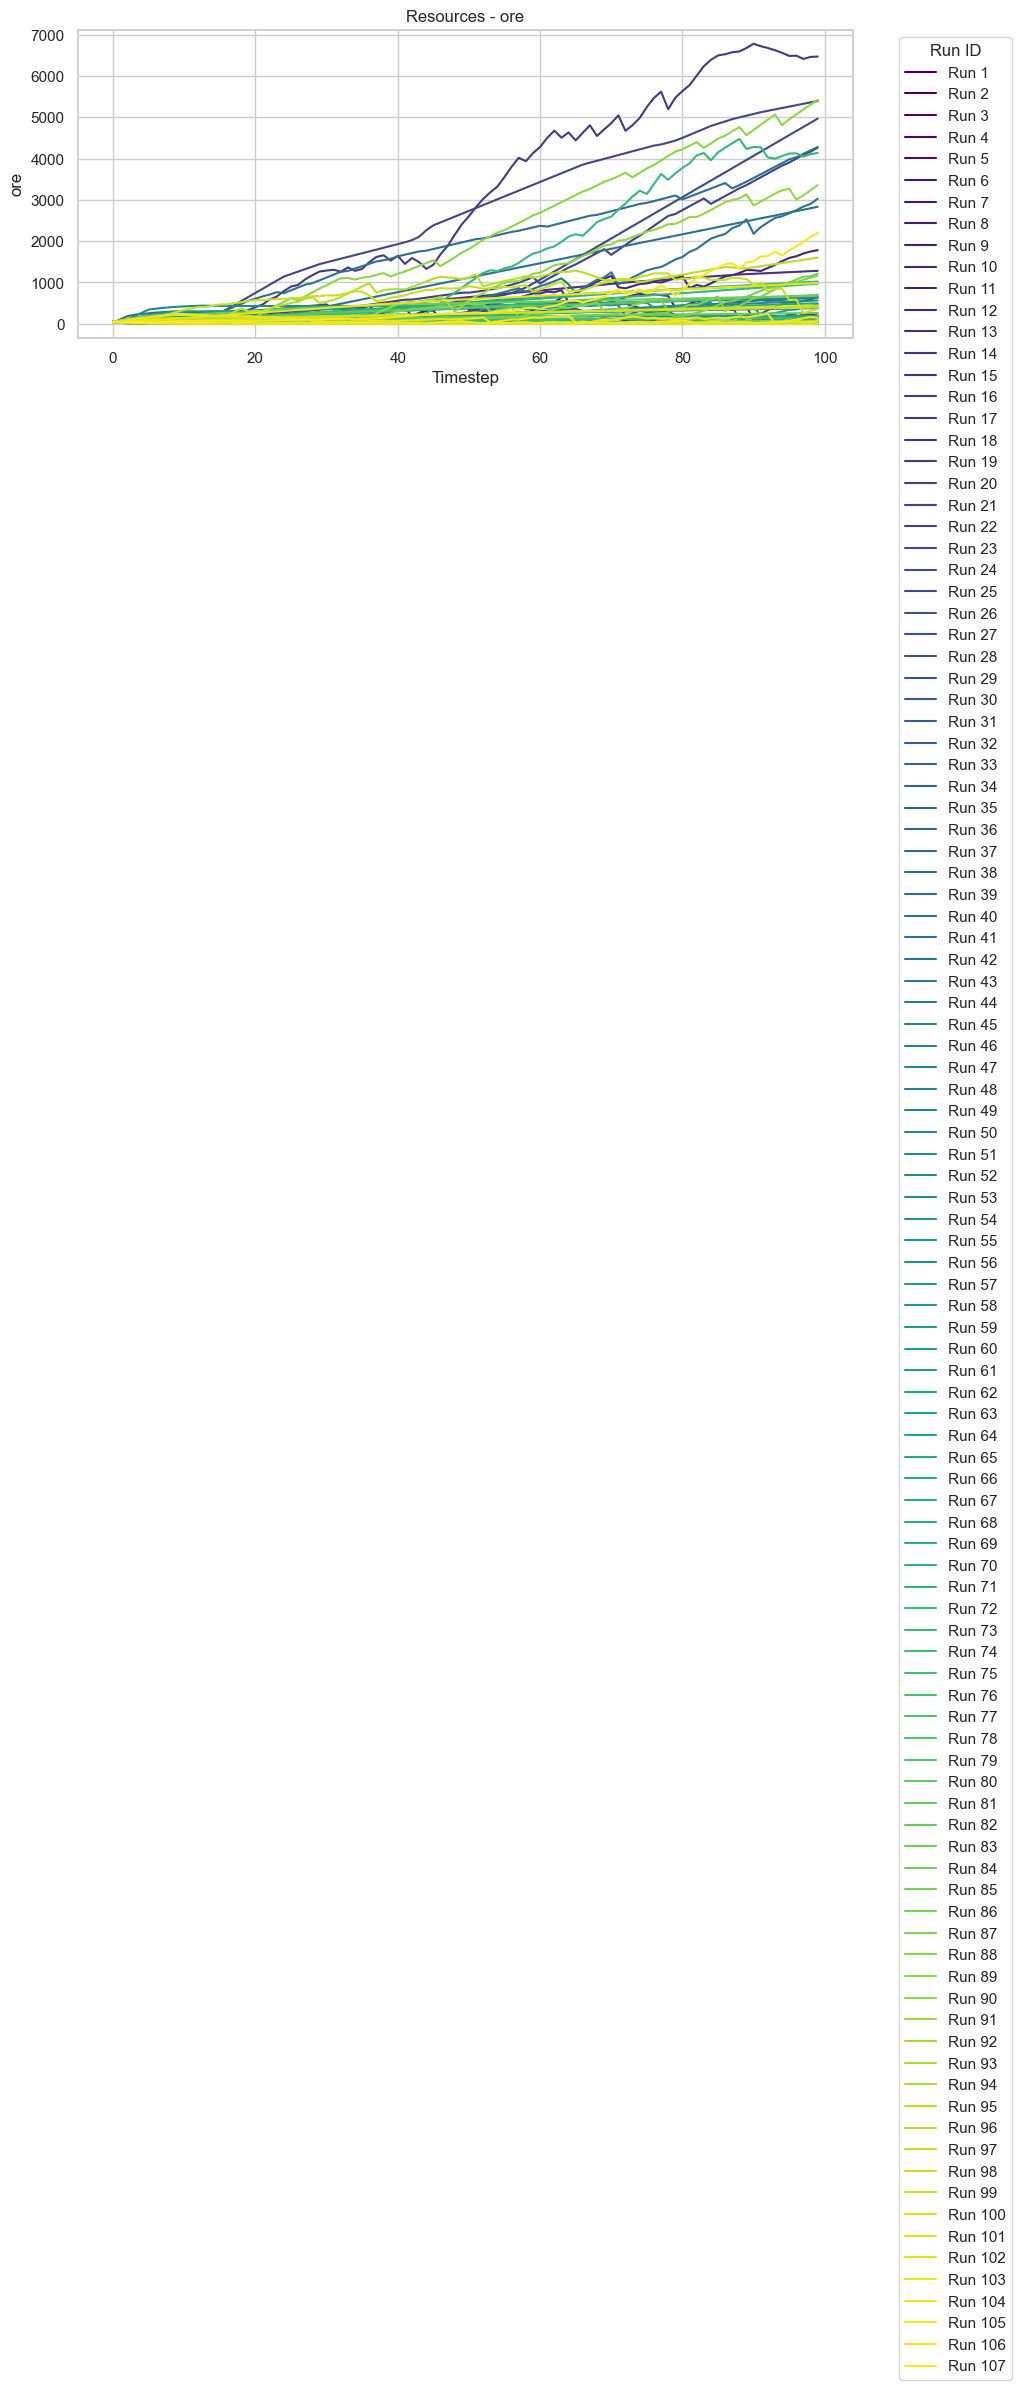

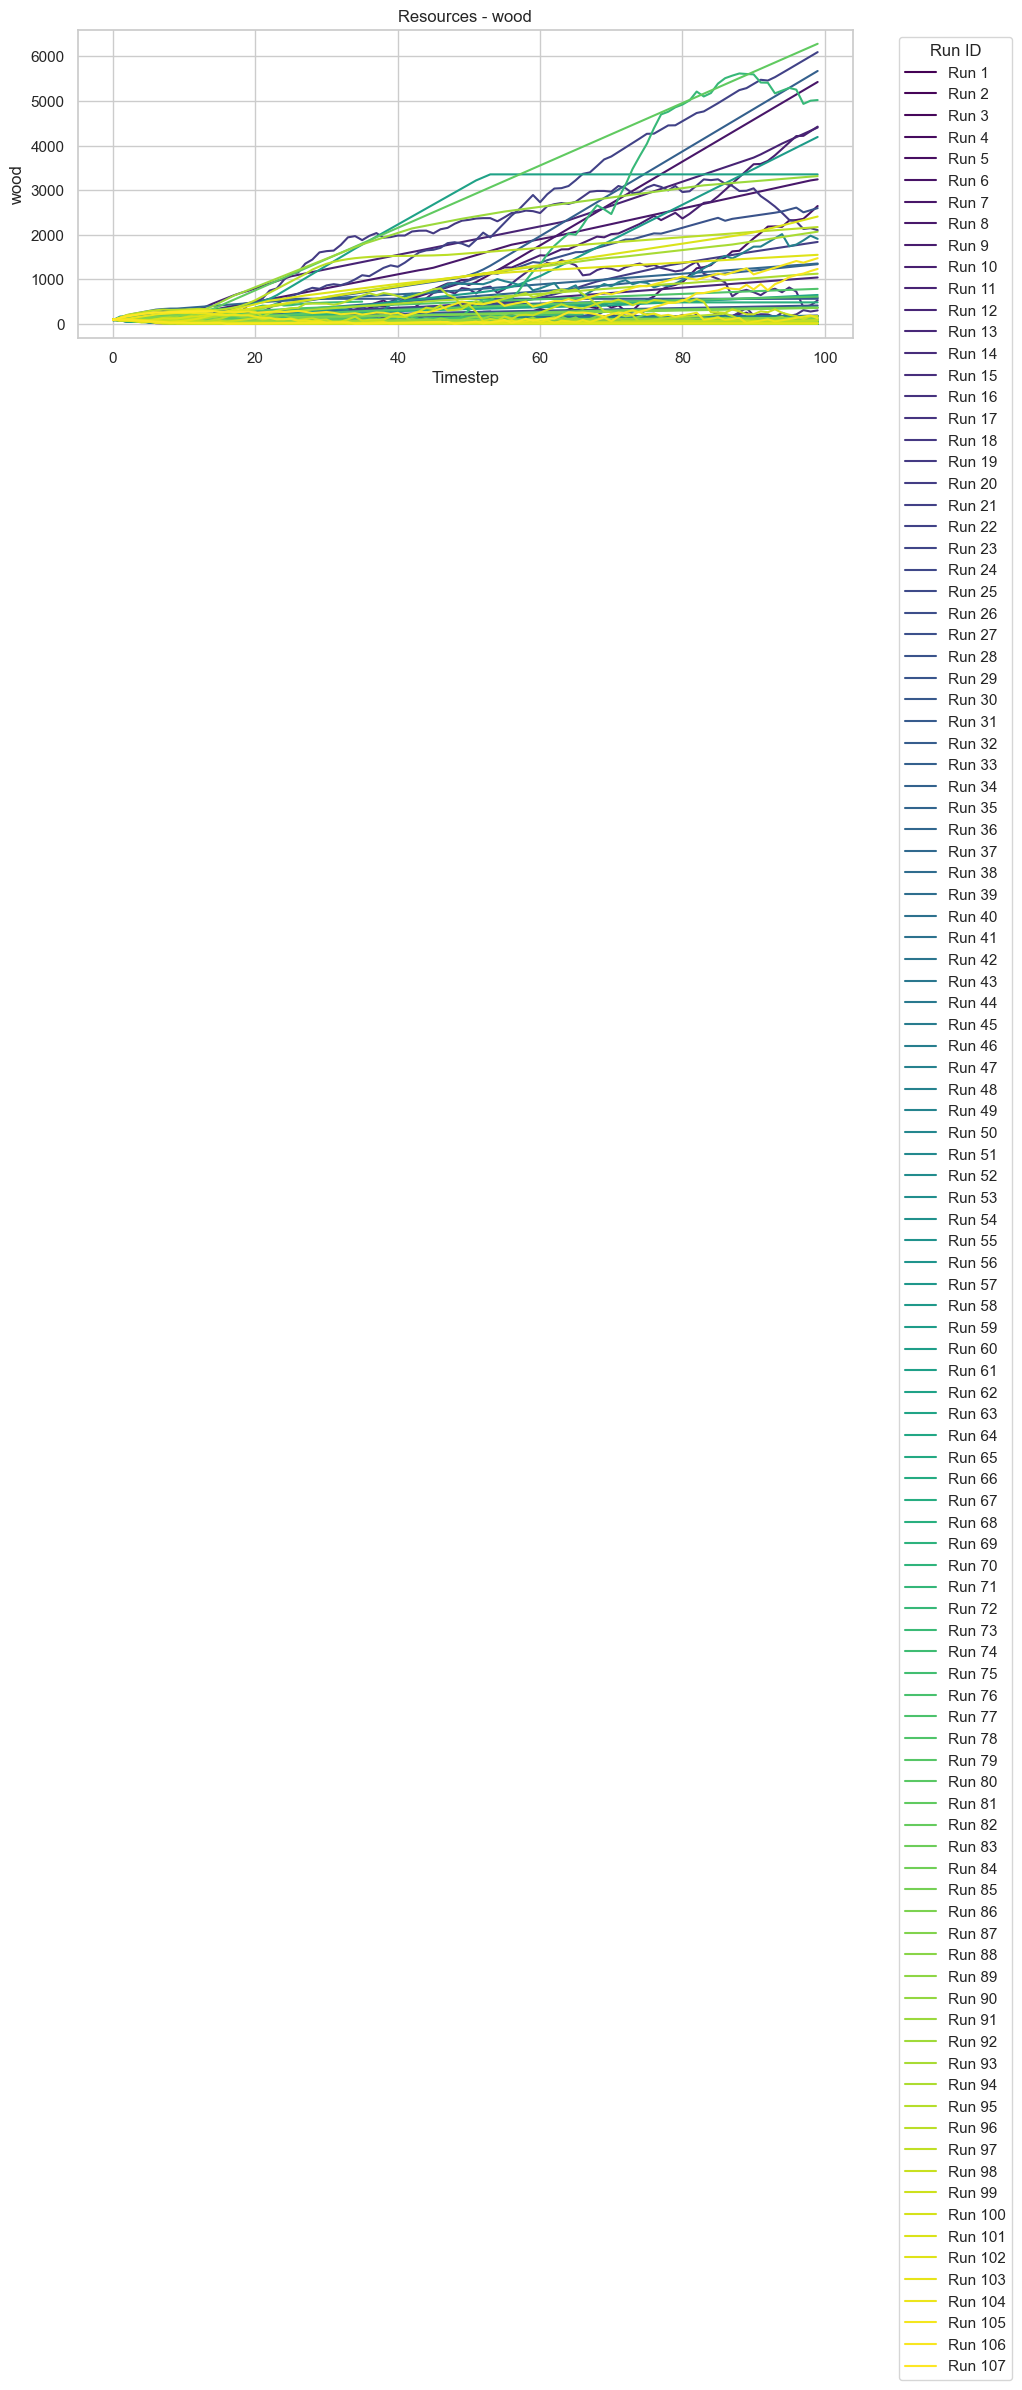

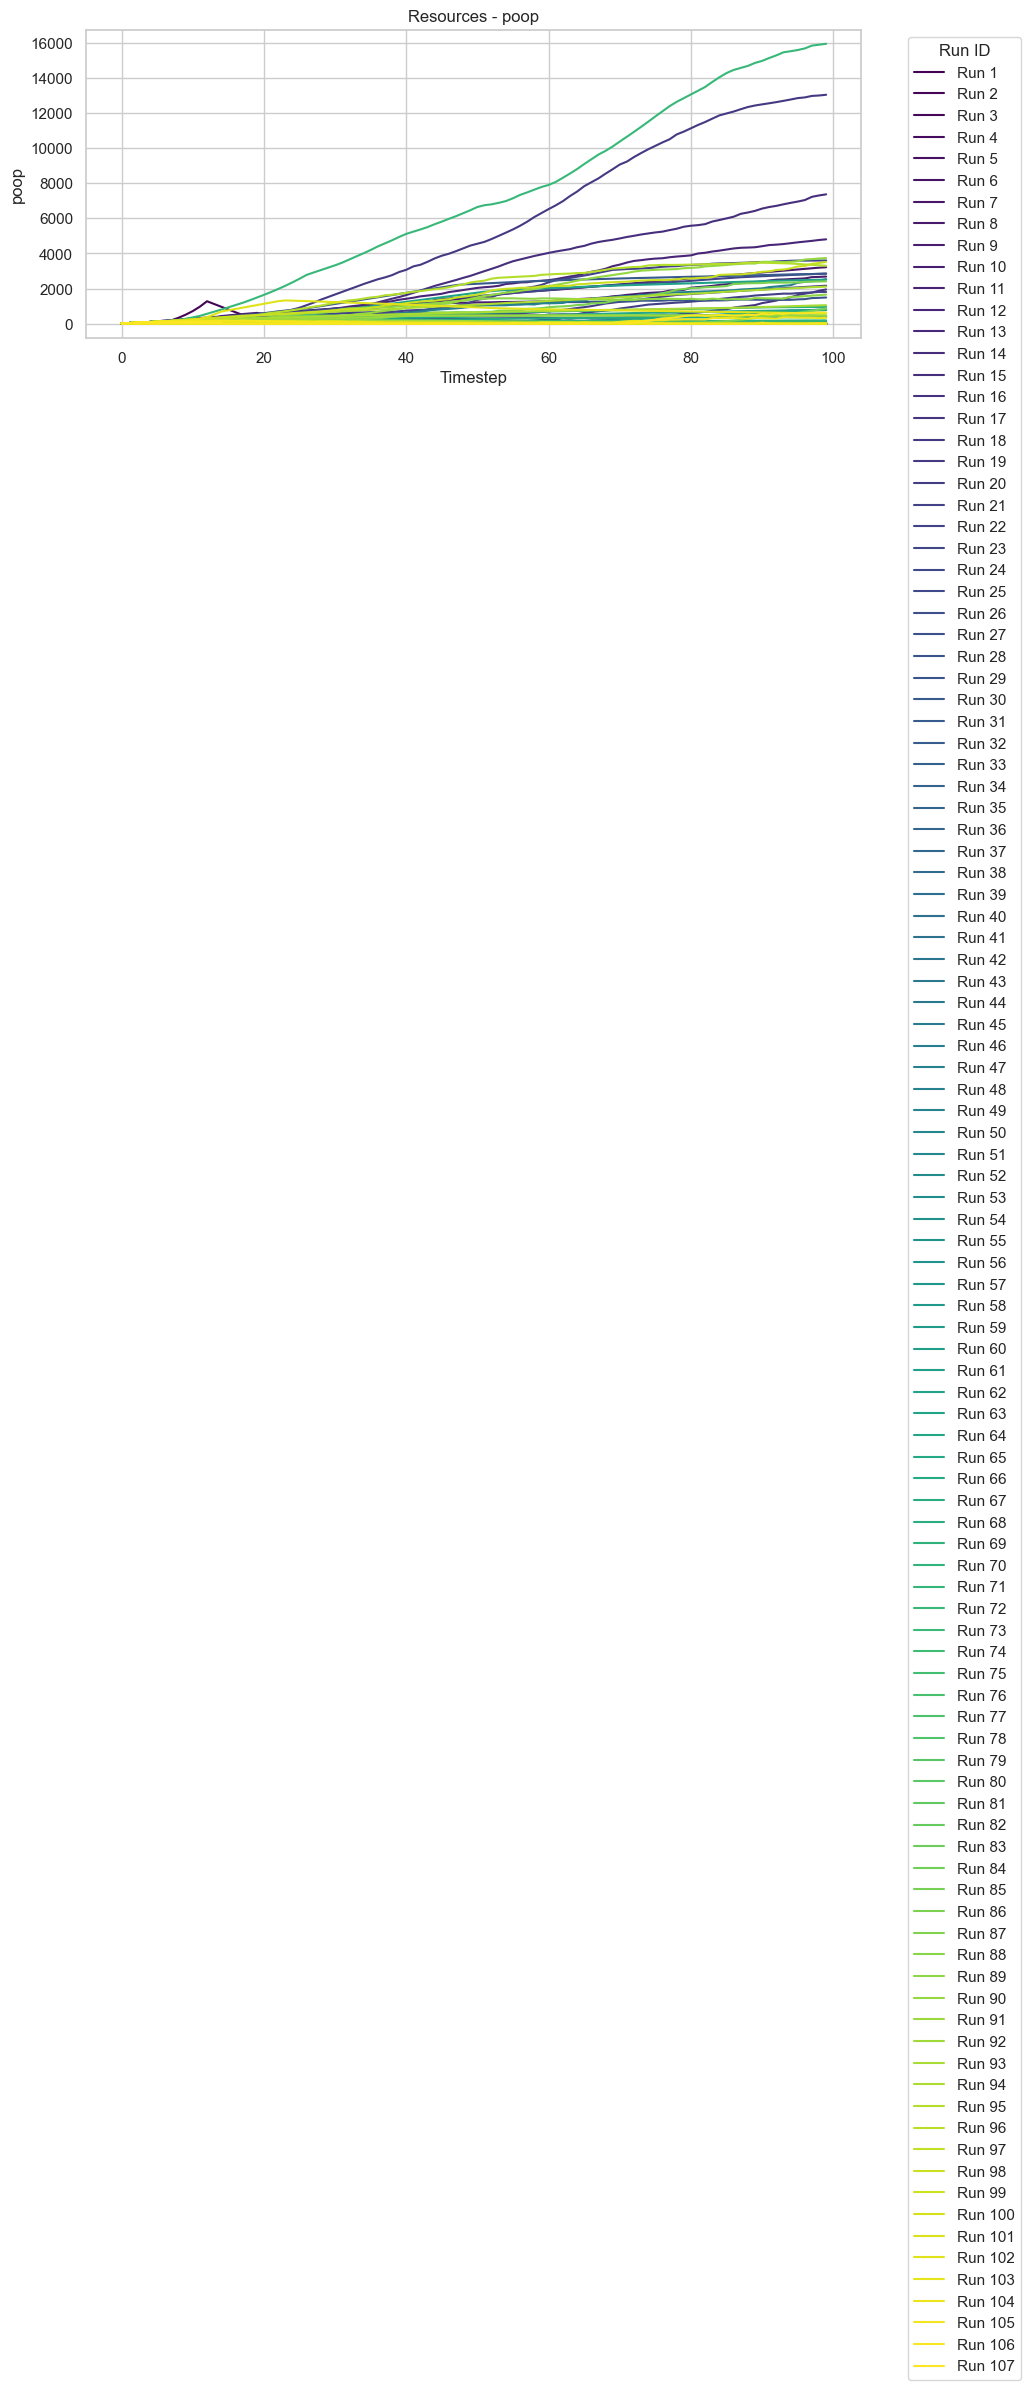

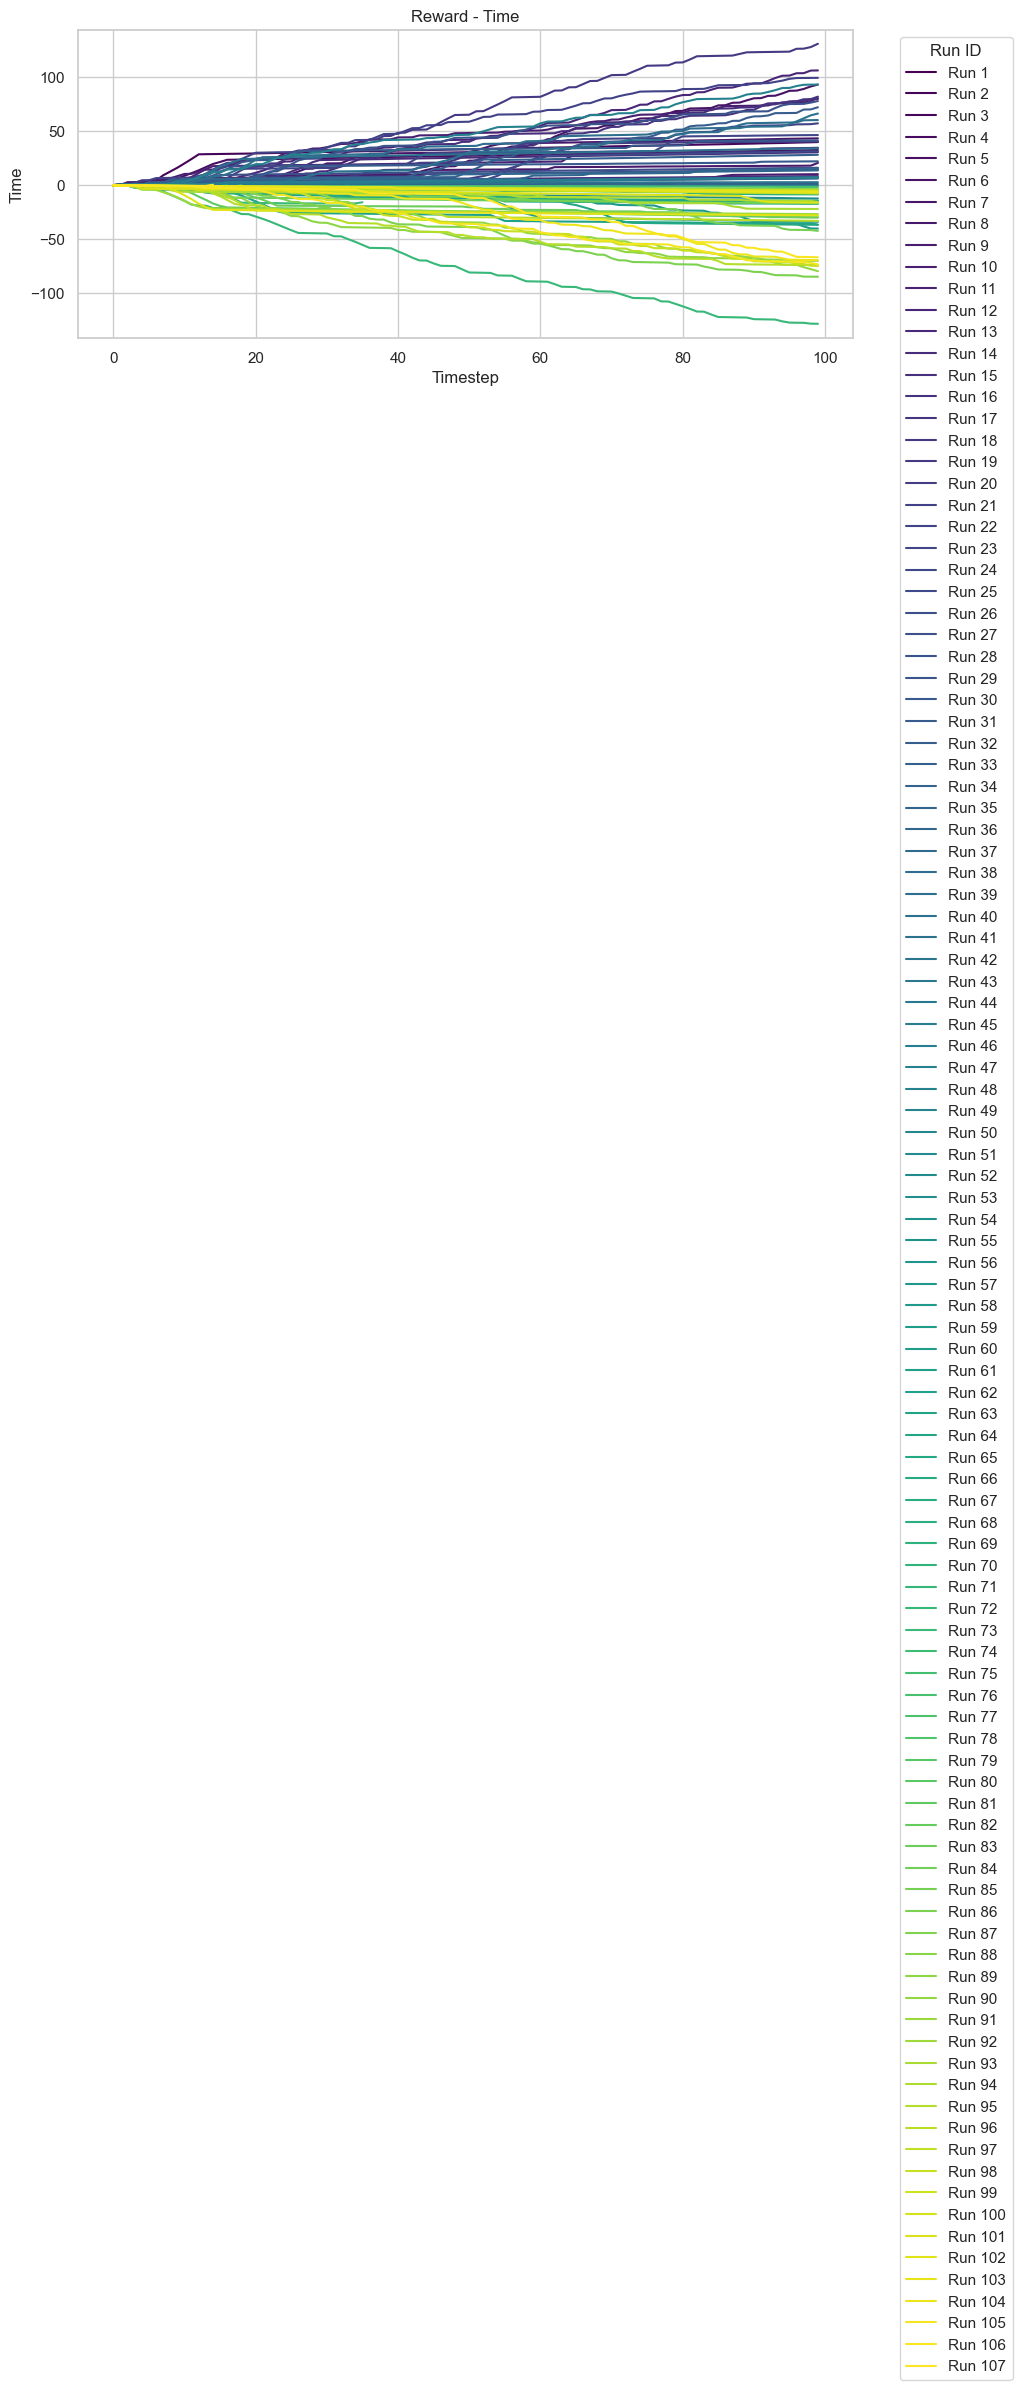

In [26]:
import matplotlib.cm as cm
import numpy as np

def plot_all_metrics(df):
    for category in df['metric_category'].unique():
        cat_df = df[df['metric_category'] == category]
        for metric in cat_df['metric_name'].unique():
            metric_df = cat_df[cat_df['metric_name'] == metric]

            # Create consistent, ordered color mapping
            run_ids = sorted(metric_df['run_id'].unique())
            num_runs = len(run_ids)
            colors = cm.viridis(np.linspace(0, 1, num_runs))
            run_id_to_color = {rid: colors[i] for i, rid in enumerate(run_ids)}

            plt.figure(figsize=(10, 4))
            for rid in run_ids:
                run_data = metric_df[metric_df['run_id'] == rid]
                plt.plot(run_data['timestep'], run_data['value'], label=f'Run {rid}', color=run_id_to_color[rid])

            plt.title(f'{category.title()} - {metric}')
            plt.xlabel('Timestep')
            plt.ylabel(metric)
            plt.legend(title='Run ID', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()

plot_all_metrics(df_long)


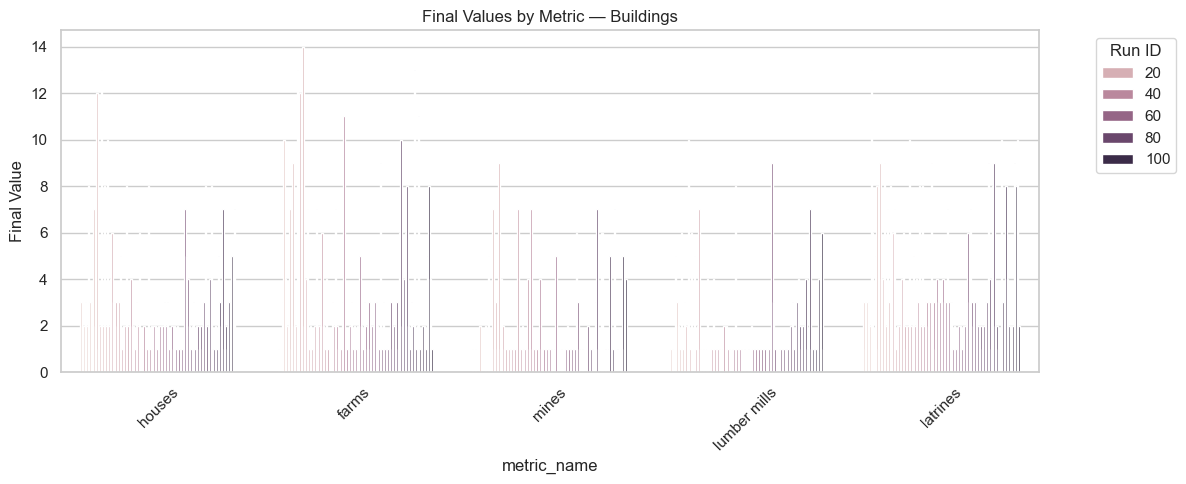

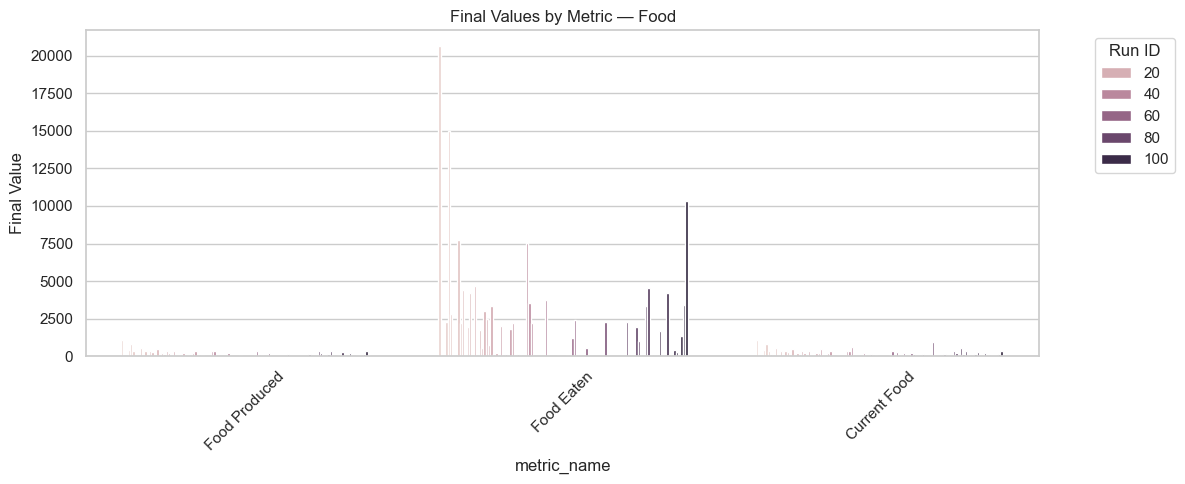

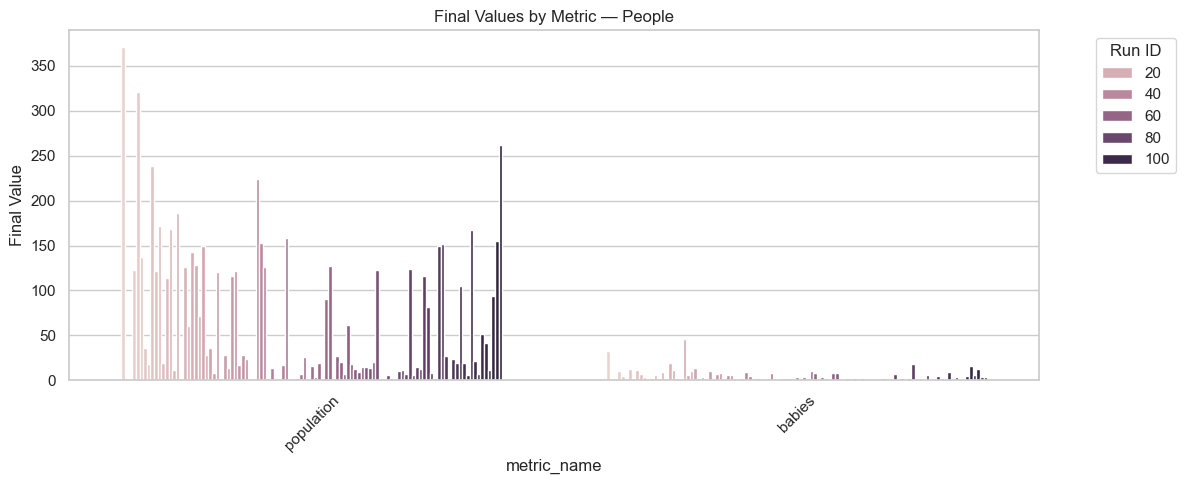

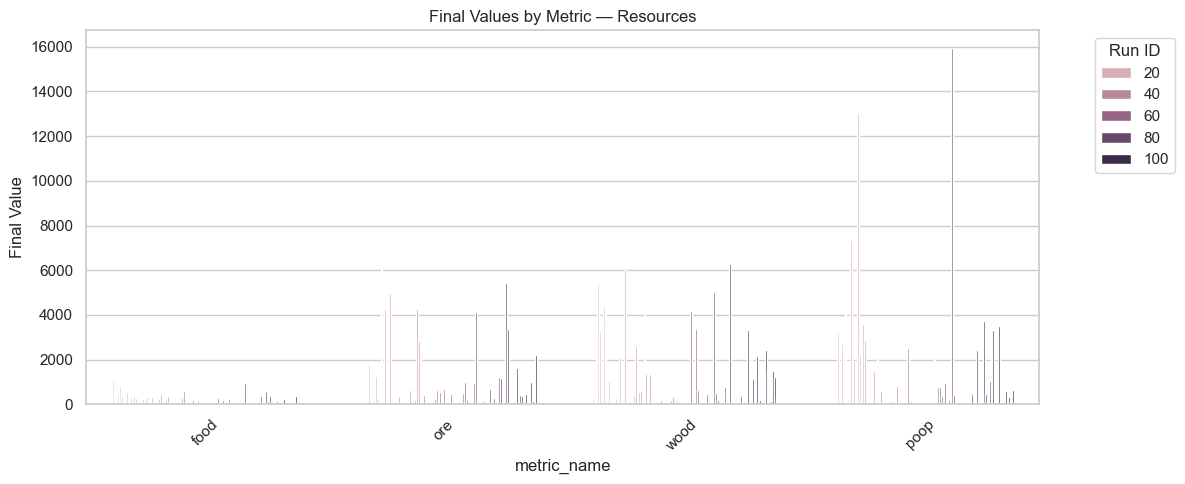

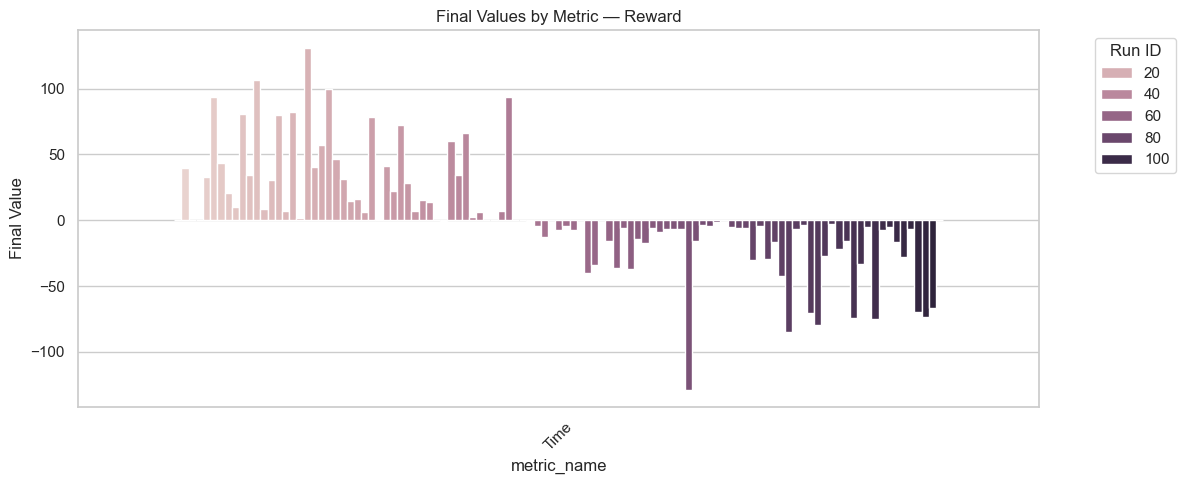

In [27]:
def plot_final_values(df):
    final_df = df.groupby(['run_id', 'metric_category', 'metric_name']).tail(1)

    for category in final_df['metric_category'].unique():
        cat_df = final_df[final_df['metric_category'] == category]
        plt.figure(figsize=(12, 5))
        sns.barplot(data=cat_df, x='metric_name', y='value', hue='run_id', dodge=True)
        plt.title(f'Final Values by Metric — {category.title()}')
        plt.ylabel('Final Value')
        plt.xticks(rotation=45)
        plt.legend(title='Run ID', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

plot_final_values(df_long)

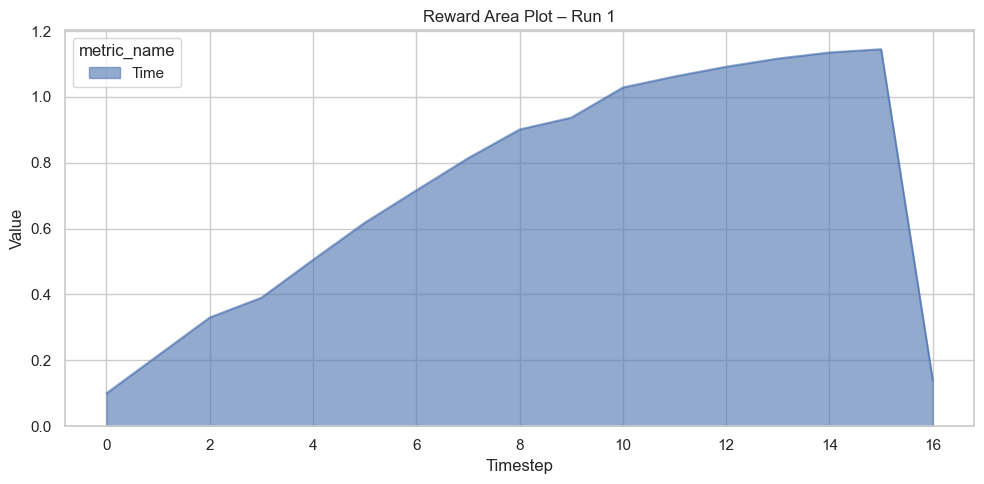

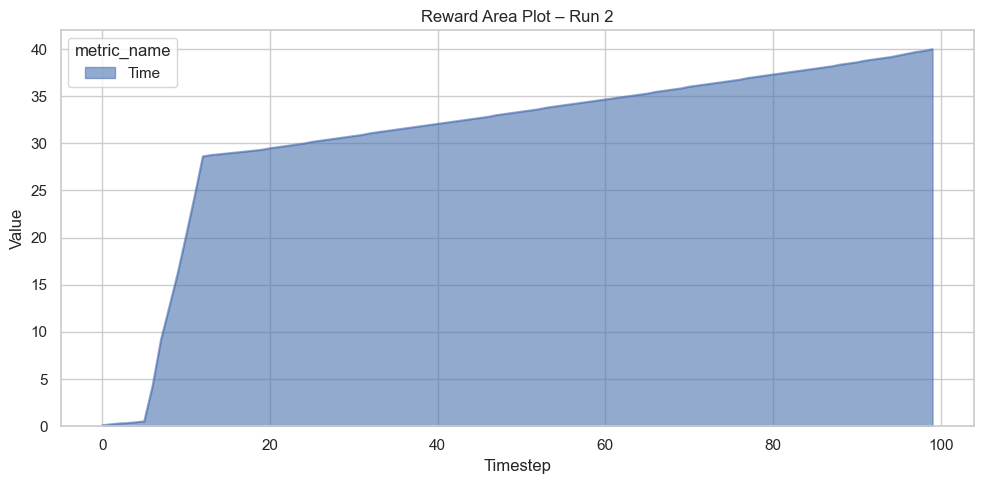

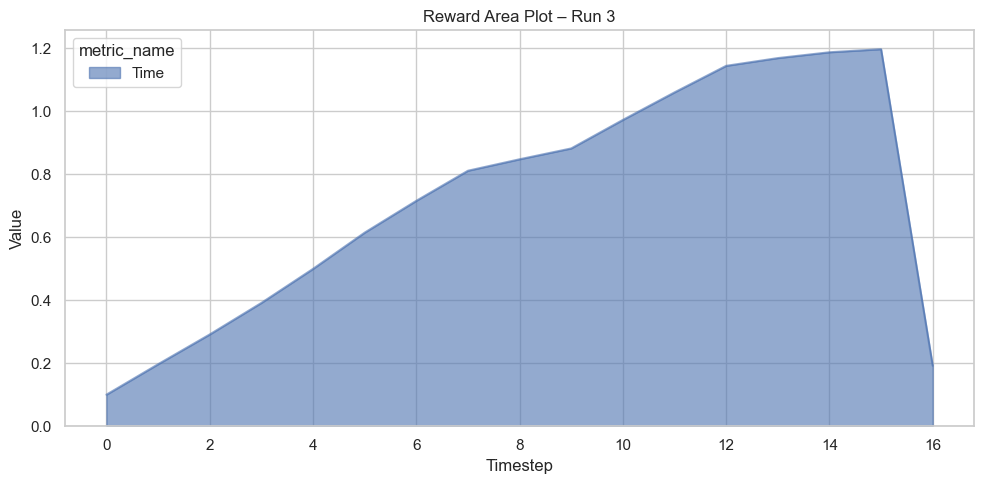

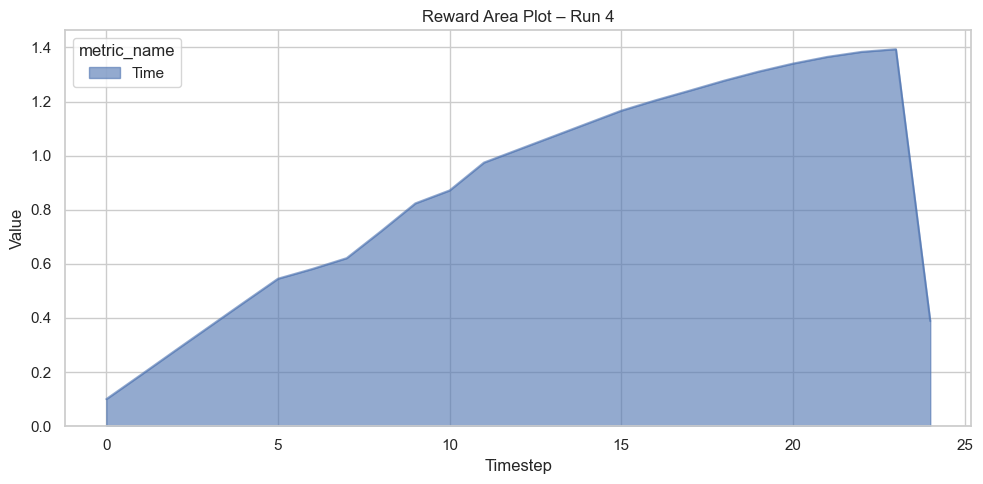

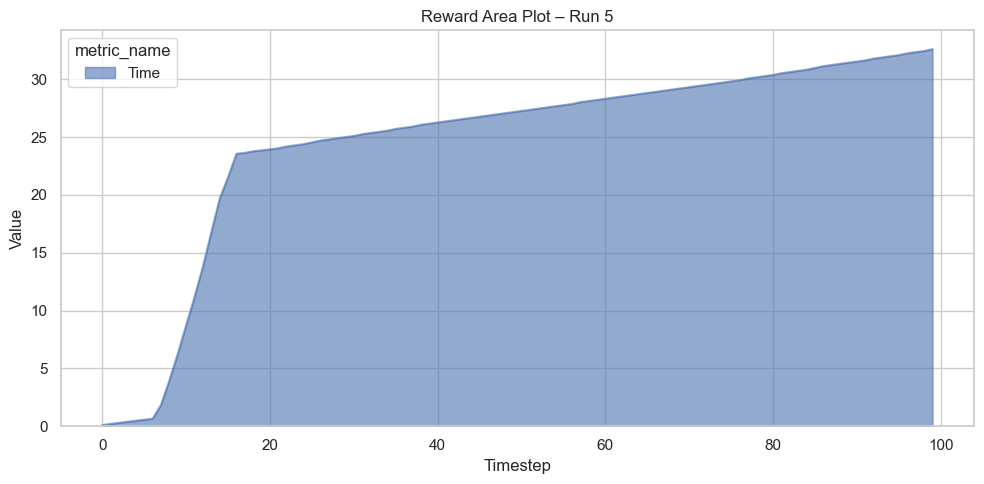

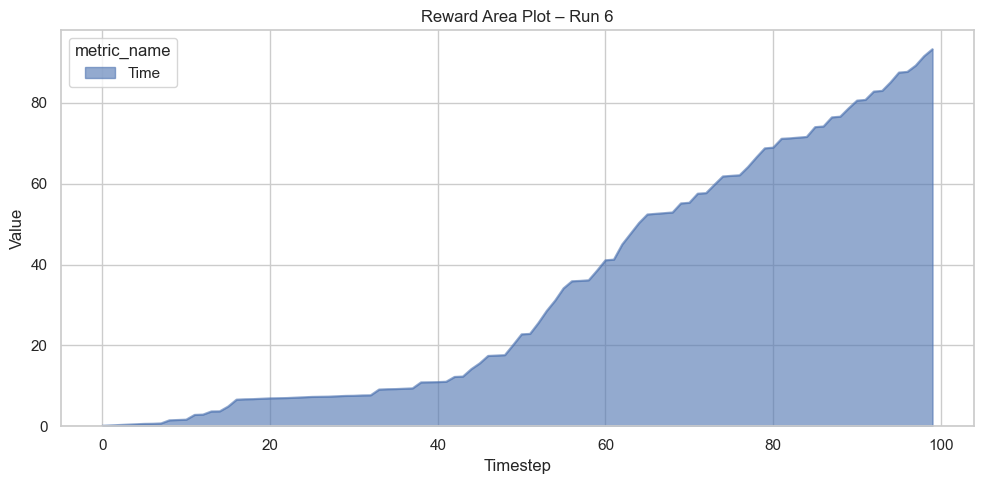

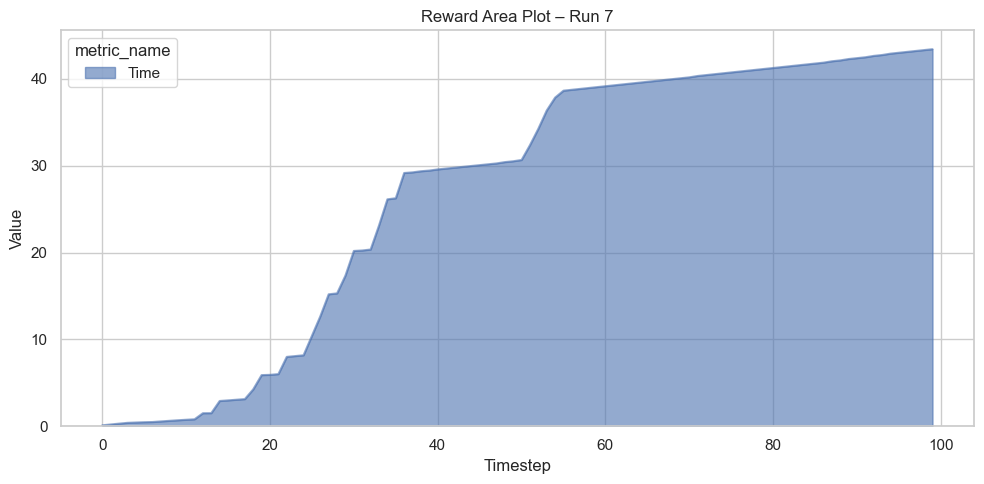

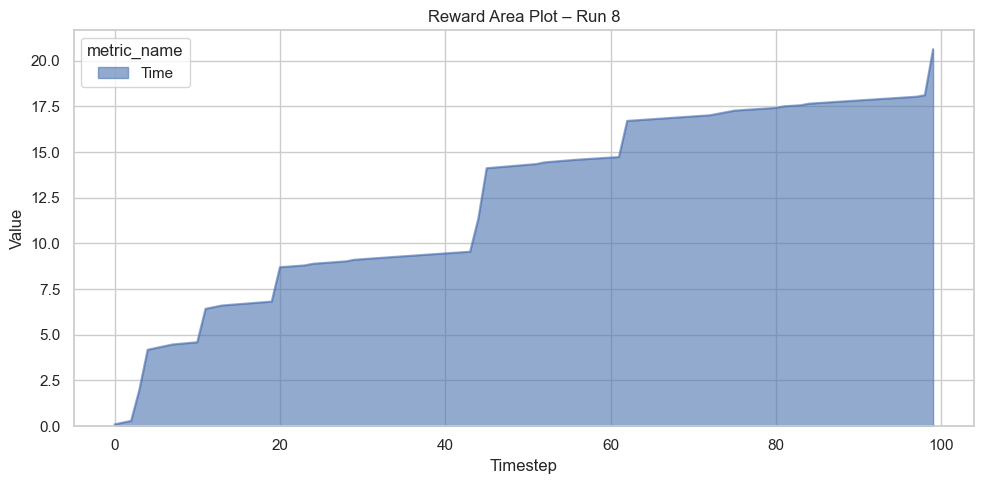

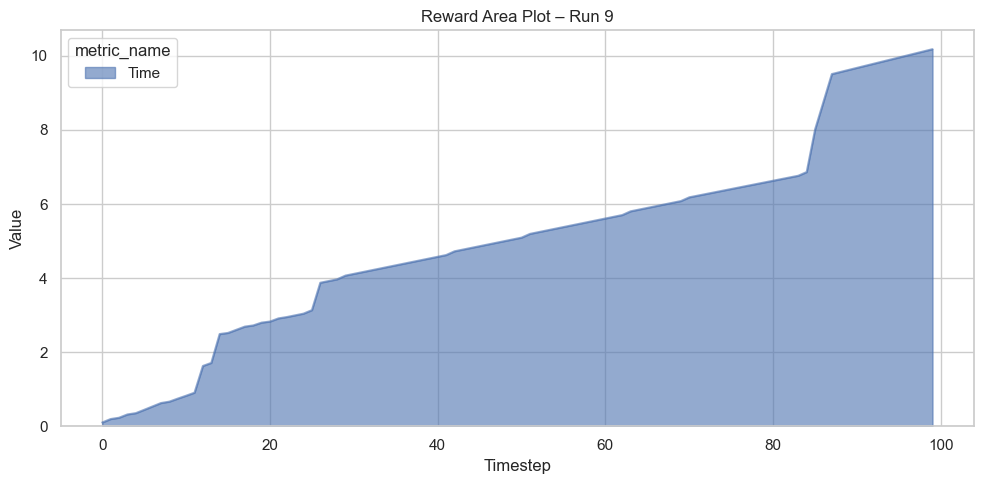

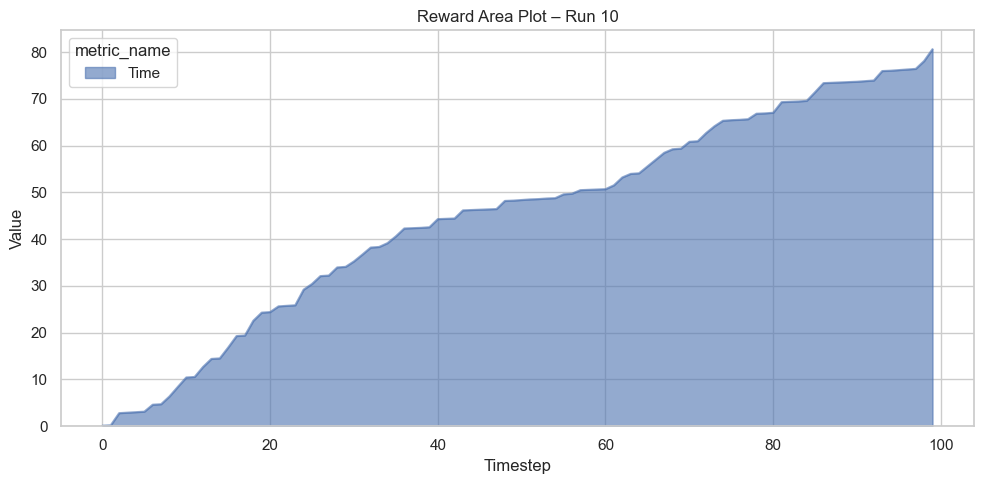

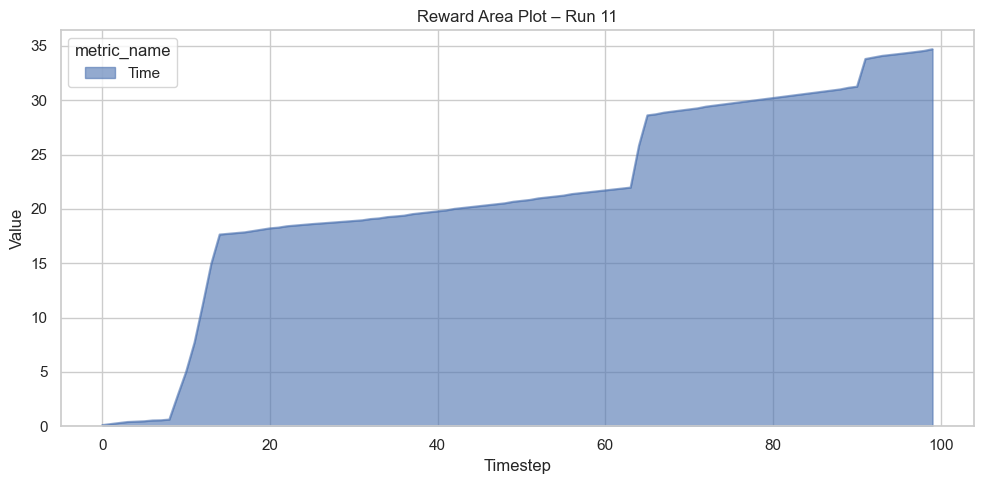

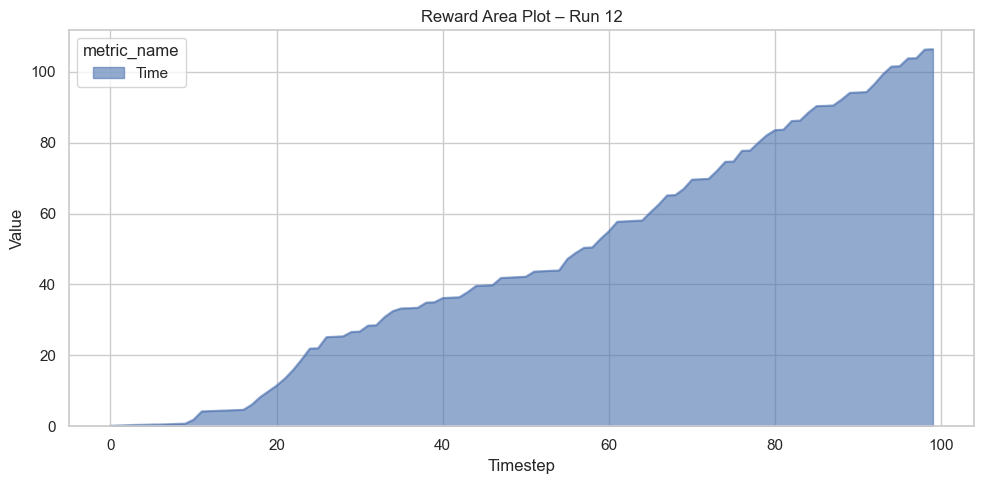

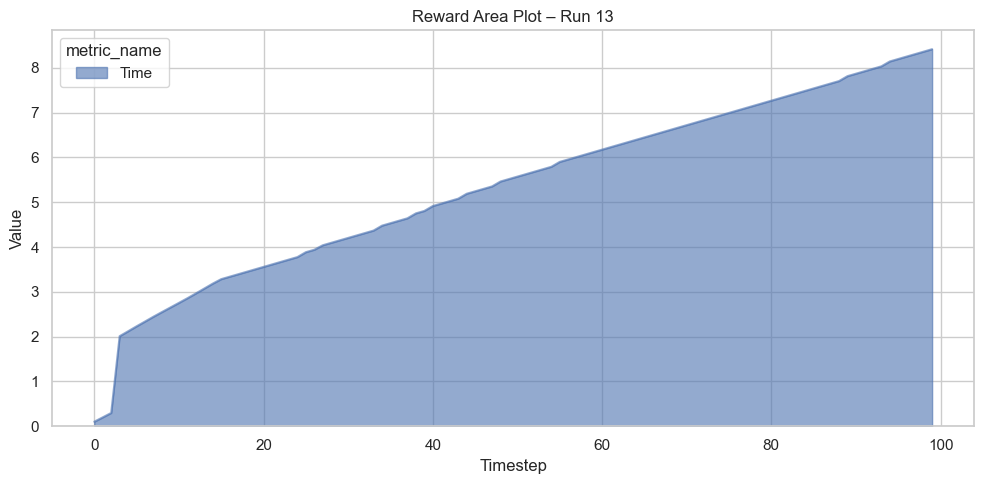

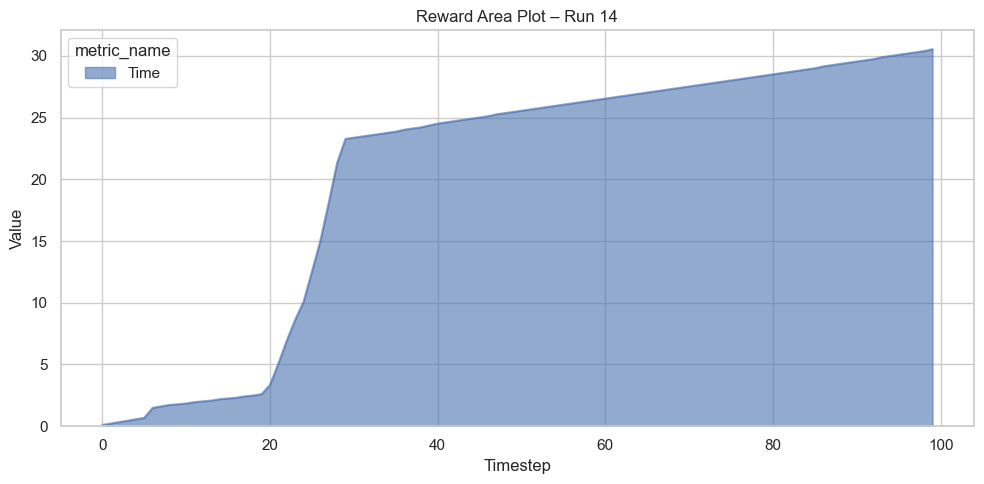

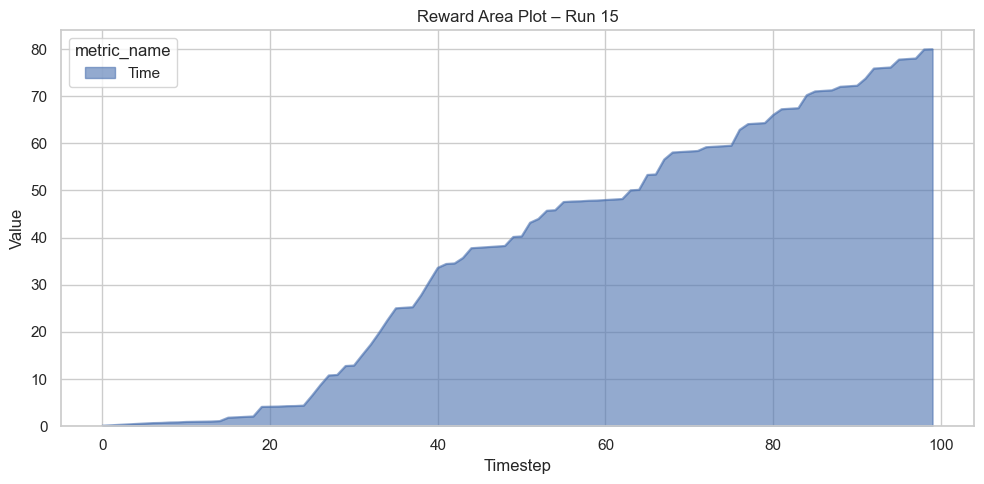

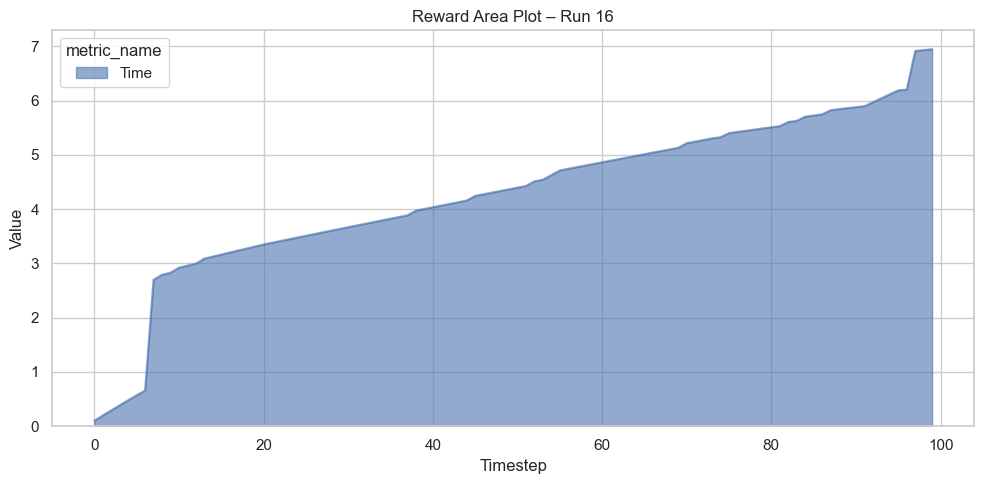

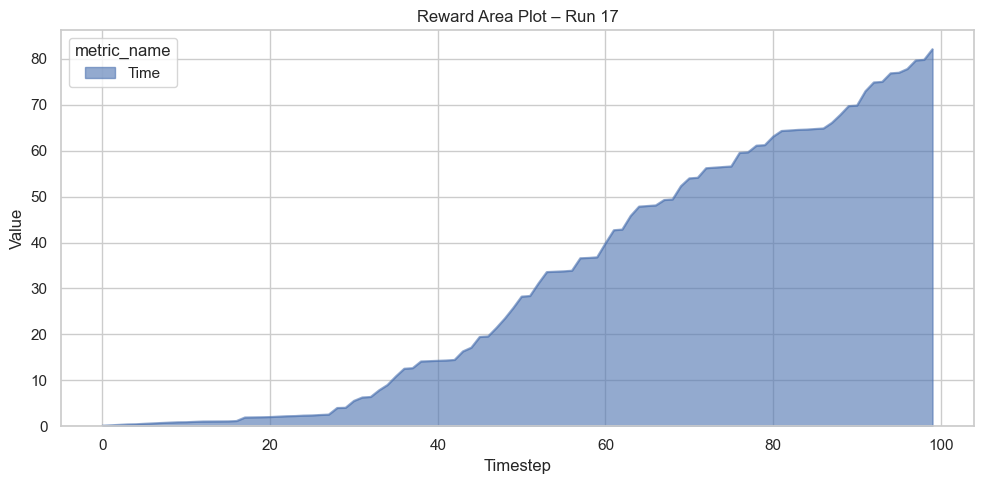

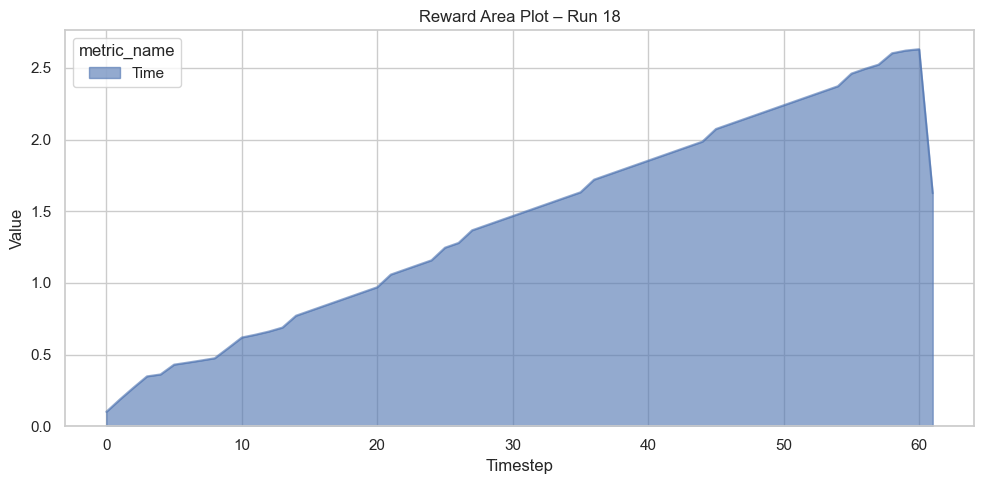

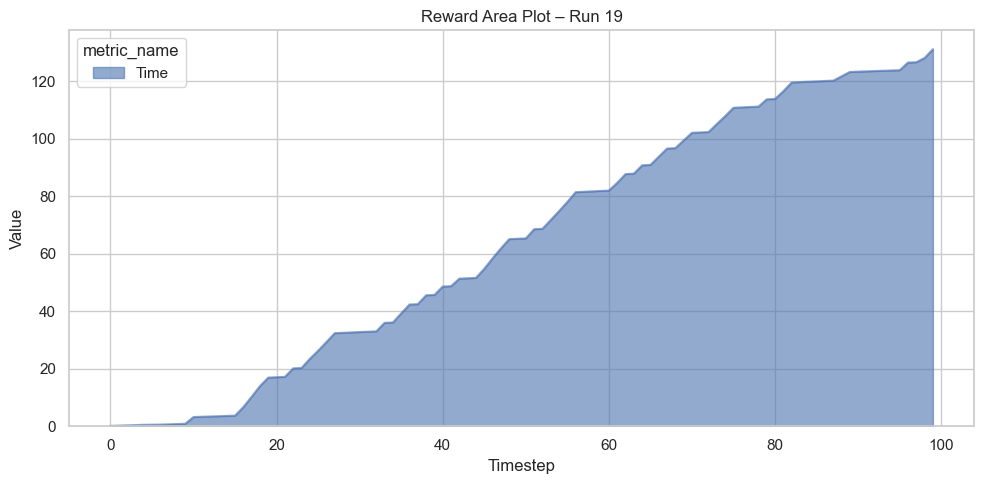

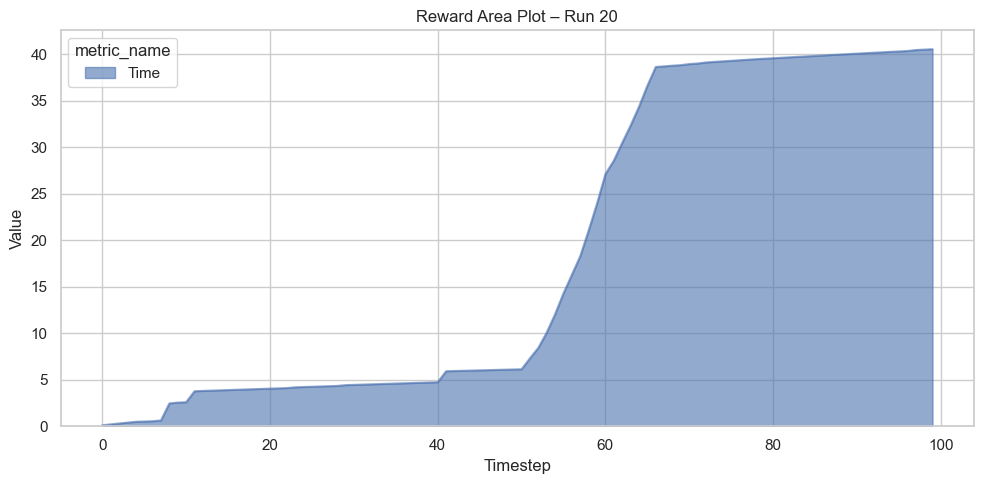

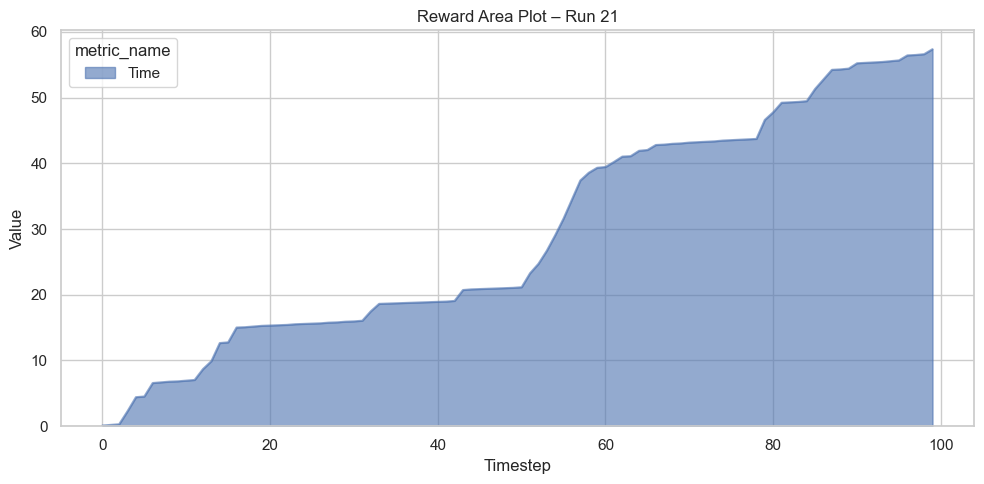

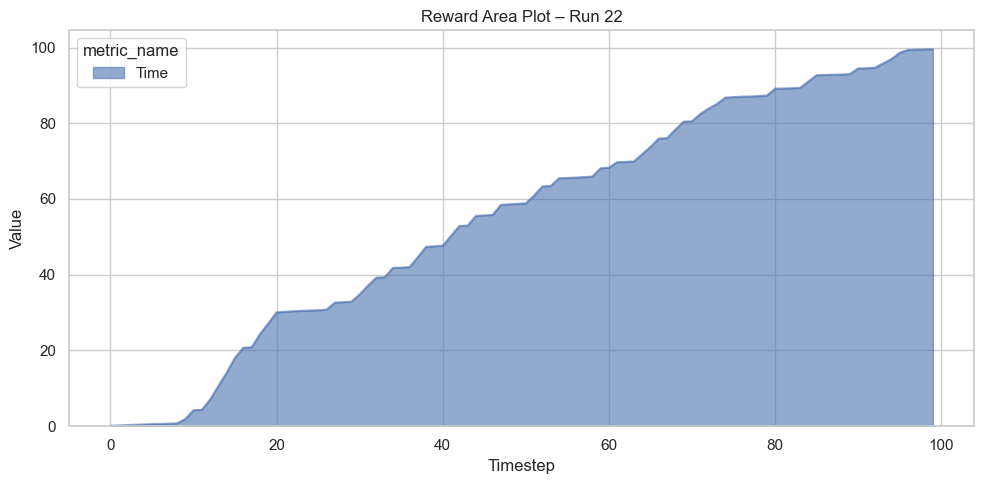

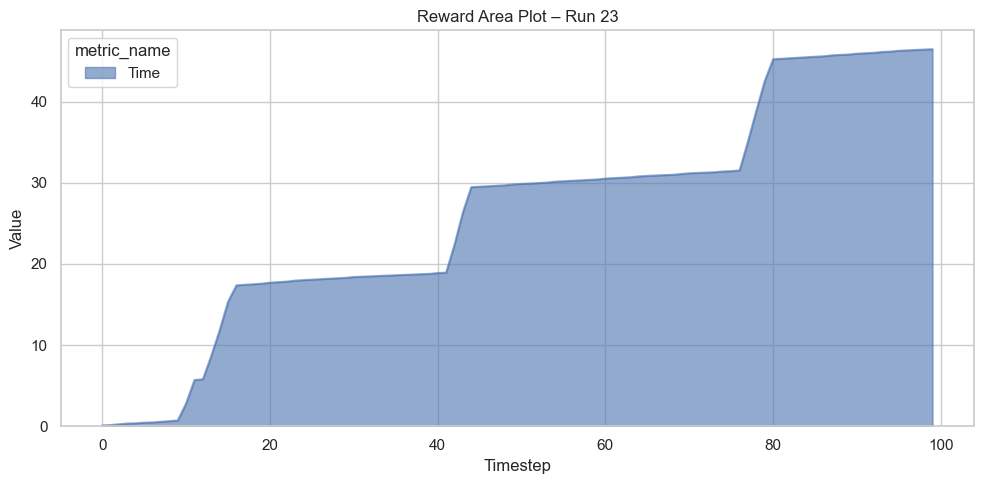

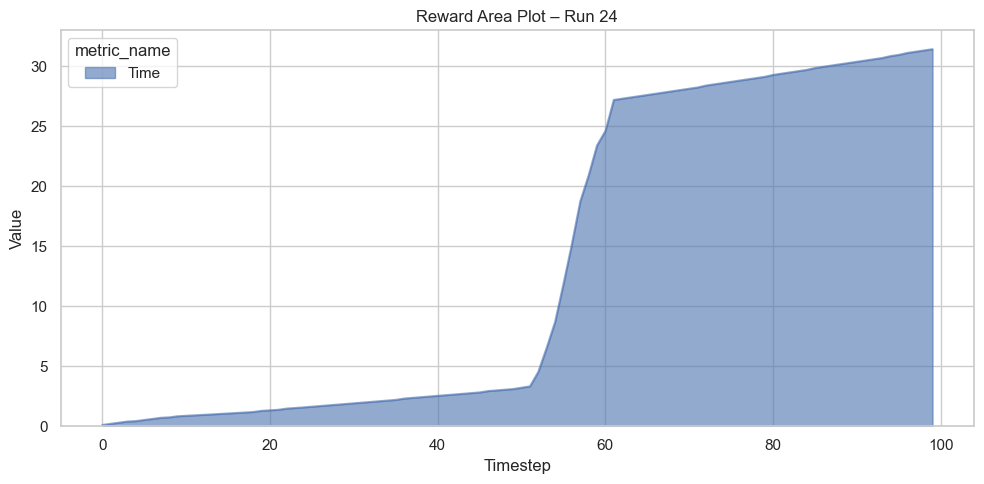

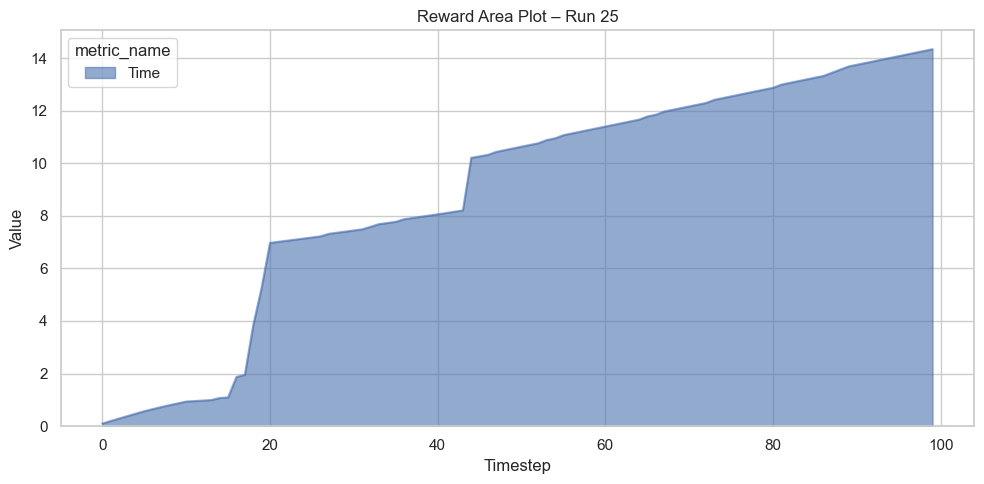

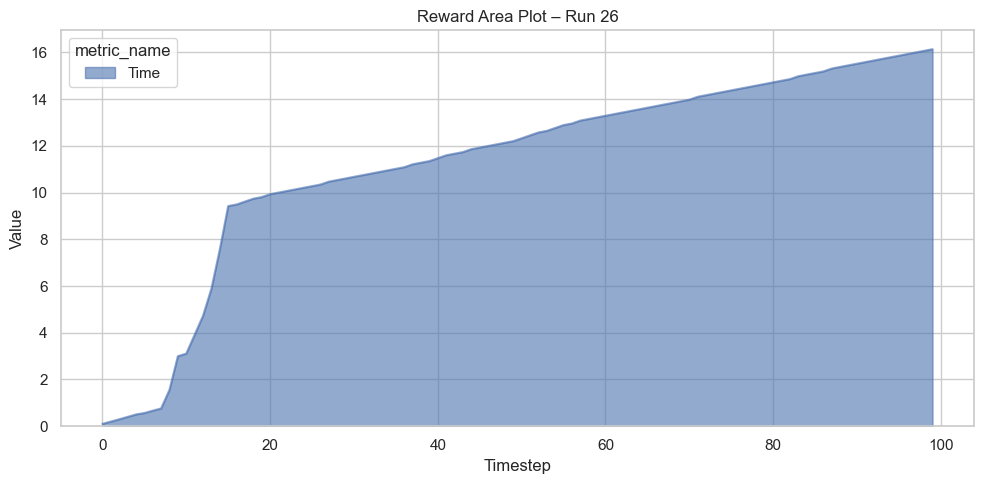

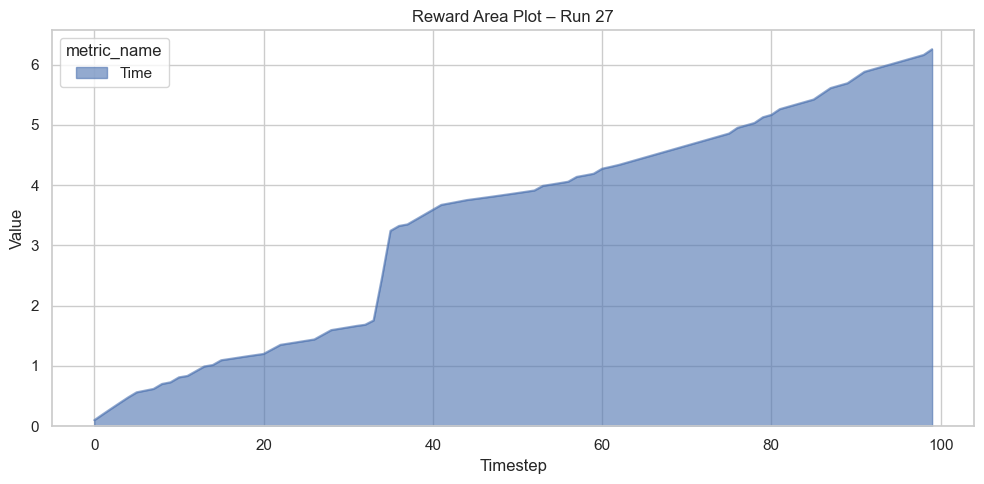

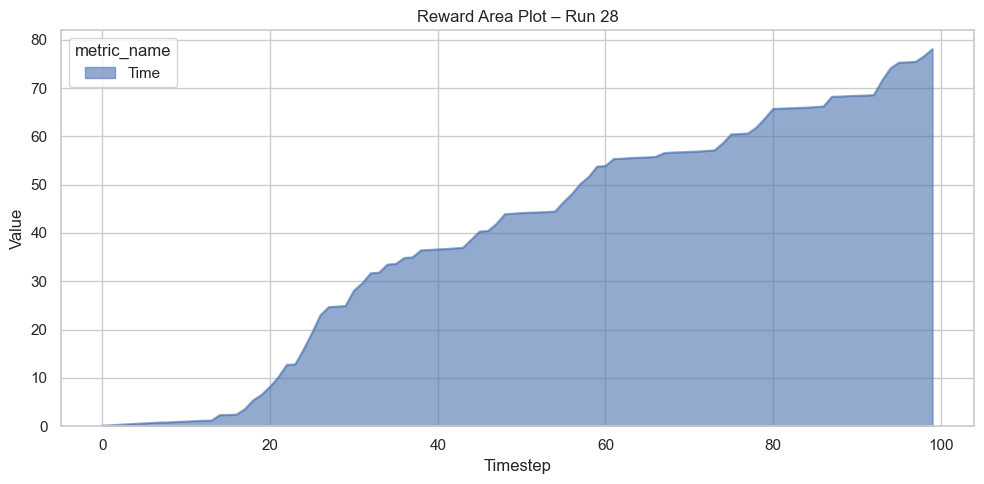

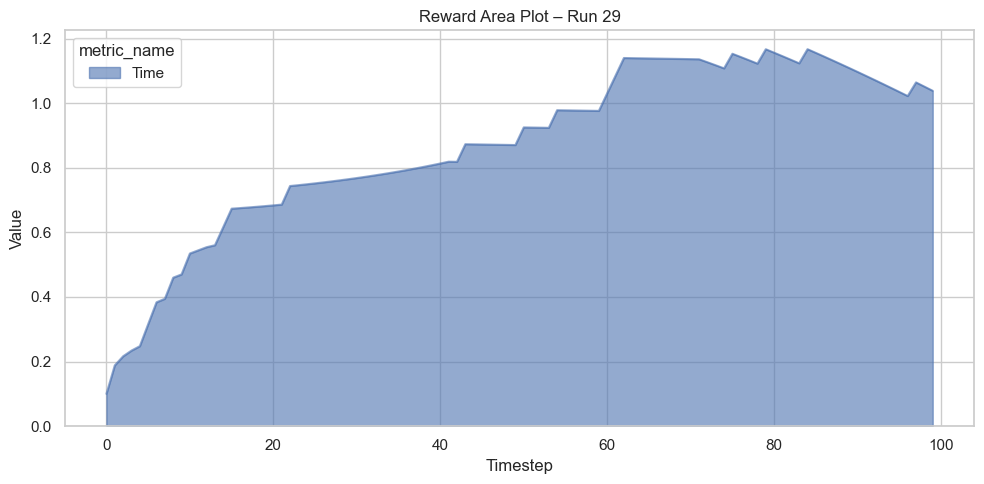

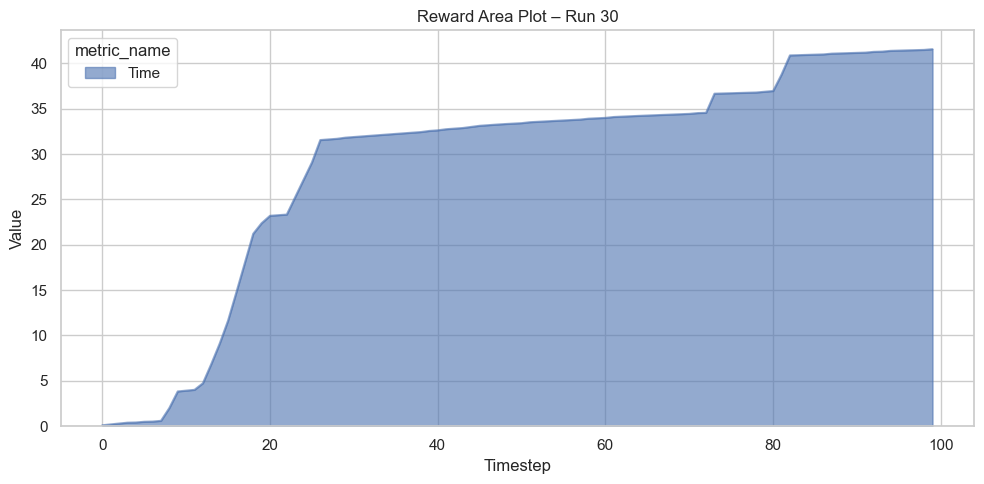

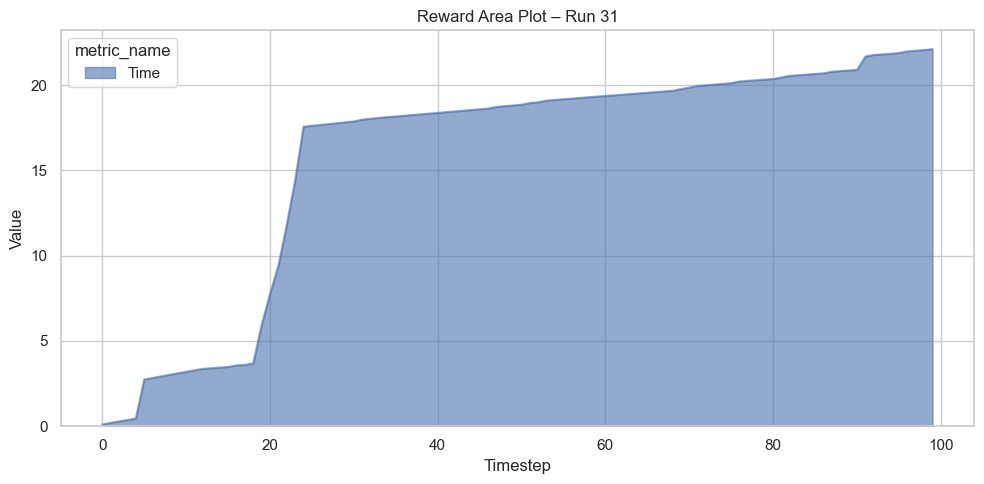

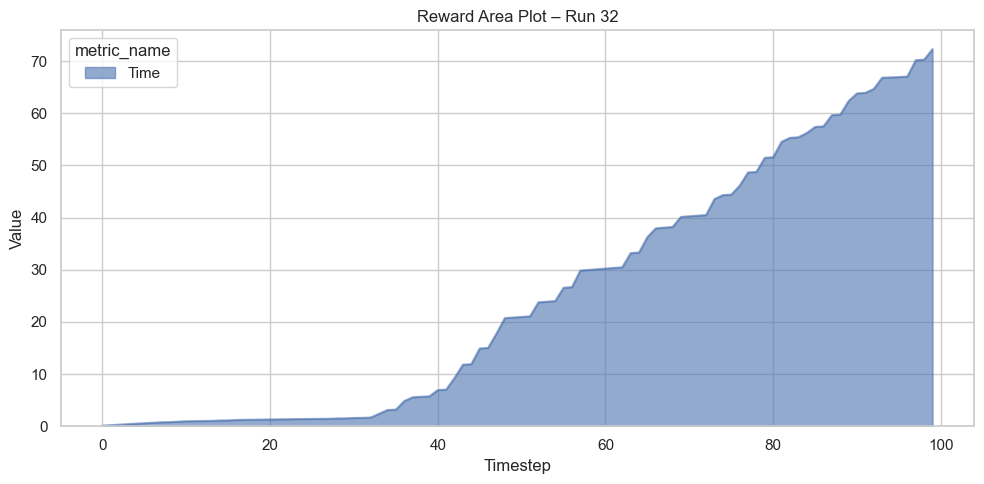

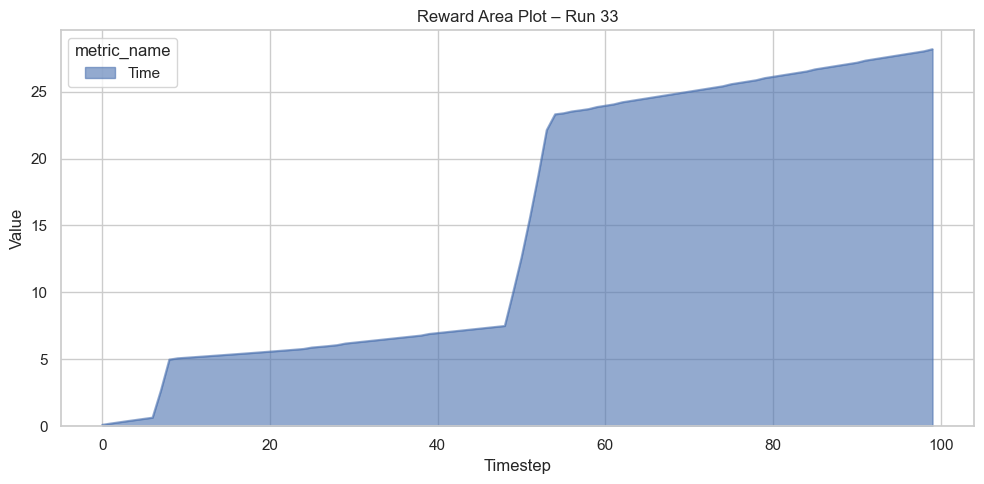

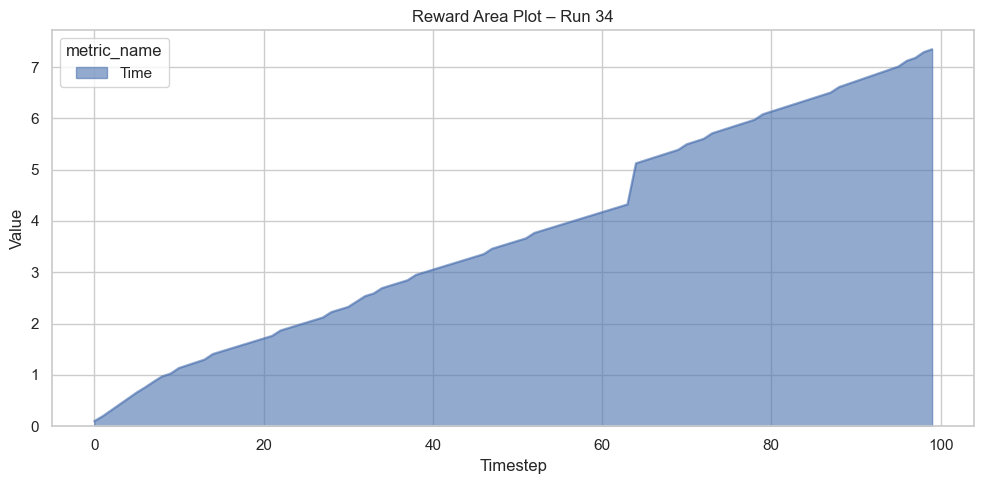

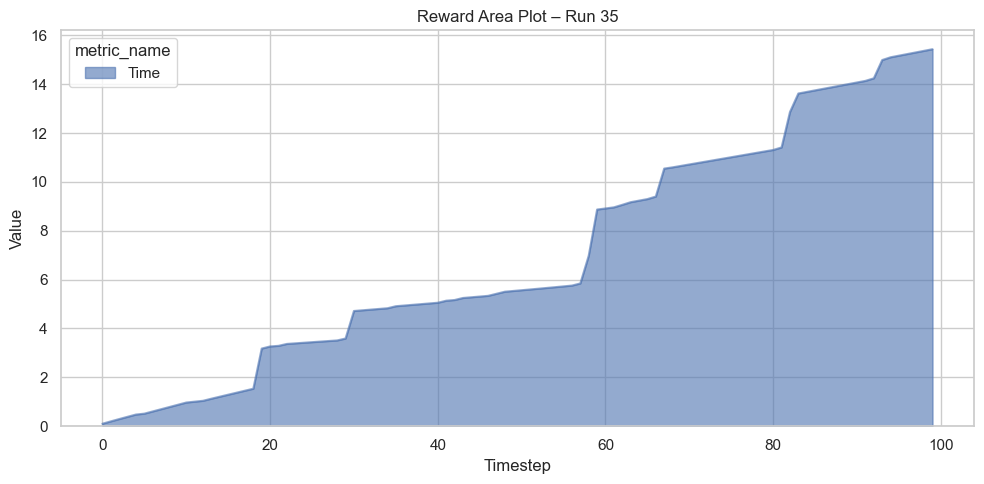

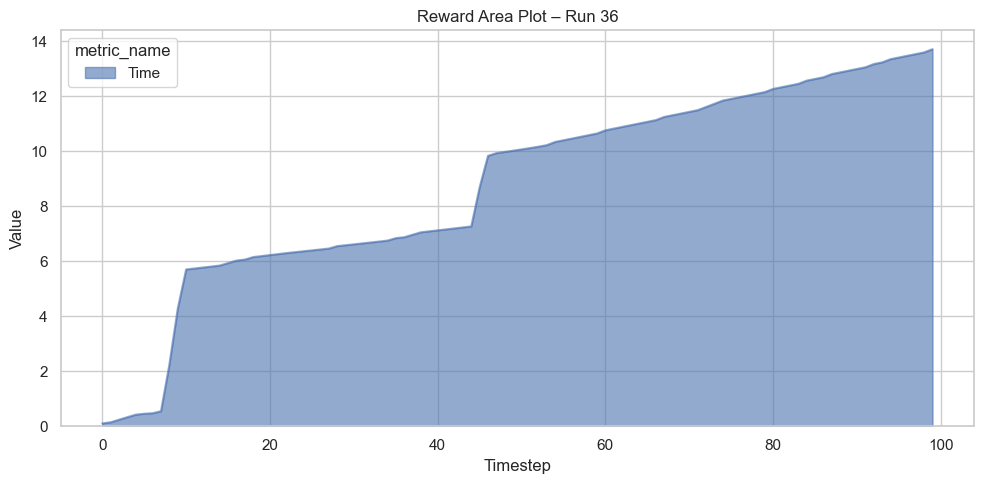

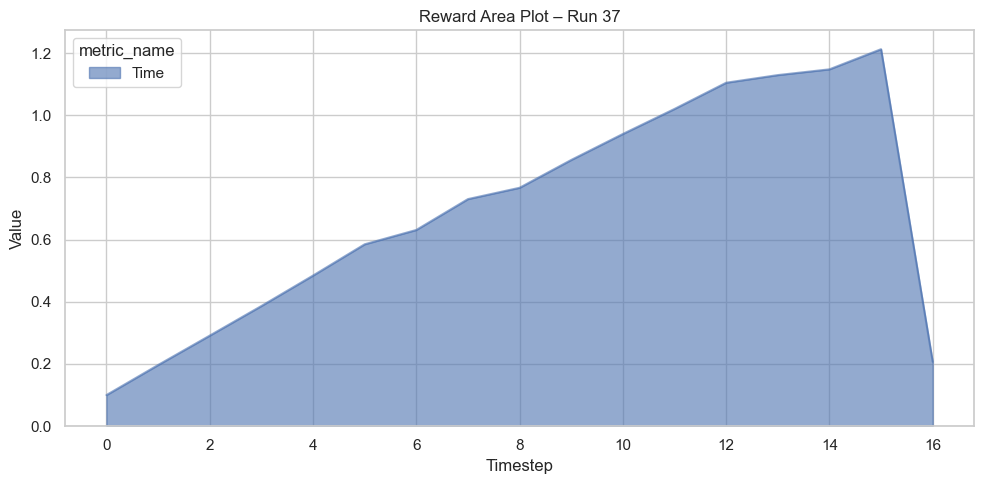

ValueError: When stacked is True, each column must be either all positive or all negative. Column 'Time' contains both positive and negative values

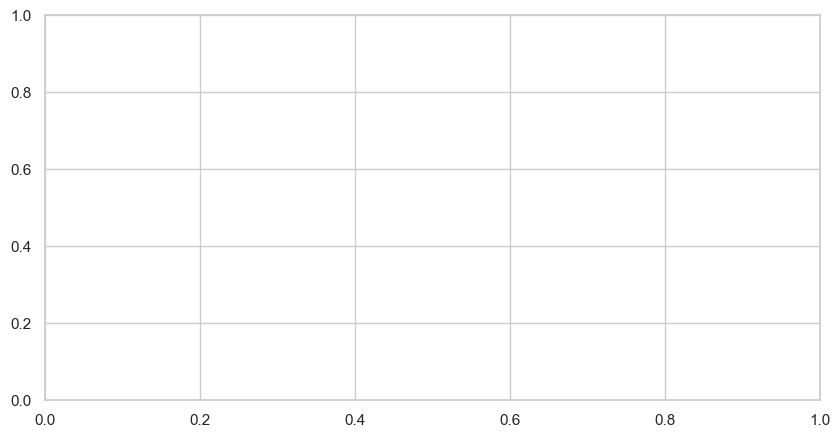

In [28]:
def plot_area_by_category(df, category_name):
    area_df = df[df['metric_category'] == category_name]
    pivoted = area_df.pivot_table(index=['timestep', 'run_id'], 
                                  columns='metric_name', 
                                  values='value').reset_index()

    for run_id in pivoted['run_id'].unique():
        run_df = pivoted[pivoted['run_id'] == run_id].set_index('timestep')
        run_df[run_df.columns.difference(['run_id'])].plot.area(
            figsize=(10, 5), alpha=0.6, title=f'{category_name.title()} Area Plot – Run {run_id}')
        plt.ylabel('Value')
        plt.xlabel('Timestep')
        plt.tight_layout()
        plt.show()

plot_area_by_category(df_long, 'reward')

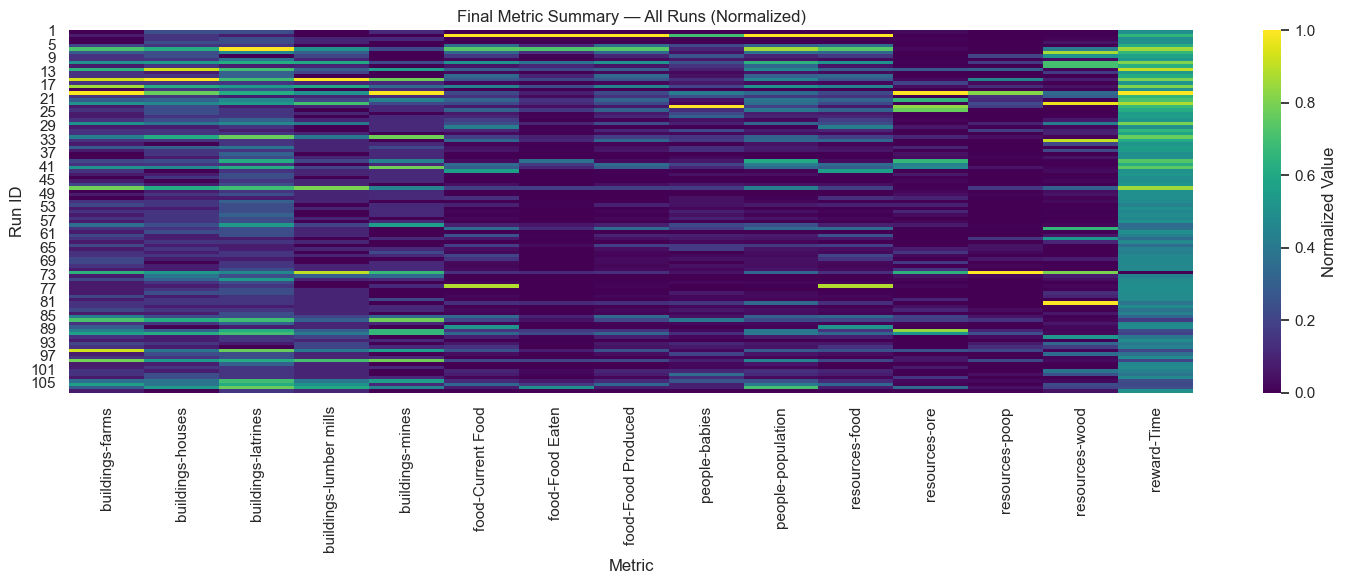

In [29]:
def heatmap_final_summary(df):
    summary = df.groupby(['run_id', 'metric_category', 'metric_name']) \
                .tail(1).pivot_table(index='run_id', 
                                     columns=['metric_category', 'metric_name'], 
                                     values='value')

    # Normalize each metric column (min-max scaling)
    normalized = (summary - summary.min()) / (summary.max() - summary.min())

    plt.figure(figsize=(15, 6))
    sns.heatmap(normalized, cmap='viridis', annot=False, cbar_kws={"label": "Normalized Value"})
    plt.title("Final Metric Summary — All Runs (Normalized)")
    plt.ylabel("Run ID")
    plt.xlabel("Metric")
    plt.tight_layout()
    plt.show()



heatmap_final_summary(df_long)